## <a id='toc1_1_'></a>[Import Data](#toc0_)

In [3]:
import os
import pickle
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter

# ==========================================
# Configuration Parameters
# ==========================================
BASE_PATH = r"C:\Users\PenPen\Desktop\Ferret\Data\3.12"
UNIQUE_TONES_PATH = r"C:\Users\PenPen\Desktop\Ferret\Data\Bohan\unique_tones\unique_tones.npy"

# Experimental paradigm and temporal resolution (dt) specifications
TASK = "playback_block"  
DT = "0.005"  # Temporal resolution (dt), directly corresponds to the numeric value in the filename

# Dynamically generate cache filename to prevent cross-contamination across different dt or tasks
CACHE_PATH = os.path.join(BASE_PATH, f"processed_cache_{TASK}_{DT}.pkl") 

# ==========================================
# Core Utility Functions
# ==========================================
def _to_feature_df(raw_feature):
    """Ensures feature data is robustly formatted as a pandas DataFrame."""
    if isinstance(raw_feature, pd.DataFrame): 
        return raw_feature.copy()
    if isinstance(raw_feature, dict): 
        return pd.DataFrame([raw_feature])
    if isinstance(raw_feature, (list, tuple)):
        if len(raw_feature) == 0: 
            return pd.DataFrame()
        if isinstance(raw_feature[0], pd.DataFrame): 
            return pd.concat(raw_feature, ignore_index=True)
    return pd.DataFrame(raw_feature)

def _normalize_n_data(raw_data):
    """Validates and normalizes neural data into a 2D numerical array."""
    arr = raw_data if isinstance(raw_data, np.ndarray) else np.asarray(raw_data)
    if arr.dtype == object: 
        raise ValueError("Neural data is object-typed; expected a numerical array.")
    if arr.ndim != 2: 
        raise ValueError(f"Neural data must be strictly 2D. Current shape: {arr.shape}")
    return arr.astype(float)

def safe_load_npy(file_path):
    """
    Enhanced diagnostic loader for .npy files. 
    Implements multi-stage deserialization to handle standard arrays, 
    pickled object arrays, and raw pickle streams.
    """
    # Stage 1: Standard NumPy loading with pickle enabled
    try:
        return np.load(file_path, allow_pickle=True)
    except Exception as e_np:
        # Stage 2: Fallback to raw pickle loading 
        # (Handles cases where files are pickled objects renamed to .npy)
        try:
            with open(file_path, 'rb') as f:
                return pickle.load(f)
        except Exception as e_pk:
            print(f"    [Warning] Dual-stage deserialization failed for: {os.path.basename(file_path)}")
            print(f"    [Diagnostic] NumPy Error: {e_np}")
            print(f"    [Diagnostic] Pickle Error: {e_pk}")
            raise IOError(f"File integrity compromised or unsupported format: {file_path}")

# ==========================================
# Main Processing Pipeline
# ==========================================
def process_raw_data(base_path, gc_or_not=True):
    """
    Parses directory for neural and feature data, aligns temporal resolutions, 
    and computes kinematic derivatives (velocity, acceleration).
    """
    n_data_dict = {}
    f_data_dict_out = {}
    global_id = 0

    # Validate spatial mapping parameters
    if not os.path.exists(UNIQUE_TONES_PATH):
        raise FileNotFoundError(f"Spatial tone mapping array not found at: {UNIQUE_TONES_PATH}")
    unique_tones_sorted = np.sort(np.load(UNIQUE_TONES_PATH))
    pixels_sorted = np.linspace(0, 28, len(unique_tones_sorted))

    # Identify subject cohorts within the directory
    all_files = os.listdir(base_path)
    subjects = set([f.split('_hs_')[0] for f in all_files if '_hs_' in f])
    print(f"[Info] Identified subject cohort: {subjects}\n")

    for subject_name in subjects:
        if subject_name not in n_data_dict:
            n_data_dict[subject_name] = []
            f_data_dict_out[subject_name] = []

        for hs in ['hs_0', 'hs_1']:
            # Construct target filenames utilizing the TASK and DT parameters
            n_file = os.path.join(base_path, f"{subject_name}_{hs}_{TASK}_{DT}_data.npy")
            f_file = os.path.join(base_path, f"{subject_name}_{hs}_{TASK}_{DT}_feature.npy")

            if not (os.path.exists(n_file) and os.path.exists(f_file)):
                continue

            try:
                n_list = safe_load_npy(n_file)
                f_list = safe_load_npy(f_file)
                
                # Standardize array structures for uniform iterative processing
                if isinstance(n_list, np.ndarray) and n_list.dtype != 'O': n_list = [n_list]
                if isinstance(f_list, (np.ndarray, pd.DataFrame)) and not isinstance(f_list, list): f_list = [f_list]

                # Incorporate cluster thresholding if specified
                gc = None
                if gc_or_not:
                    gc_path = os.path.join(base_path, 'good_clusters.npy')
                    if os.path.exists(gc_path): gc = np.load(gc_path)

                num_sessions = min(len(n_list), len(f_list))
                valid_sessions_count = 0

                for i in range(num_sessions):
                    try:
                        n_data = _normalize_n_data(n_list[i])
                        f_data = _to_feature_df(f_list[i])

                        # Apply neuron cluster filtering
                        if gc is not None:
                            valid_gc = gc[(gc >= 0) & (gc < n_data.shape[0])]
                            n_data = n_data[valid_gc, :]

                        # Standardize experimental condition flags
                        if 'Condition' in f_data.columns and 'Frequency_changes' in f_data.columns:
                            f_data.loc[f_data['Condition'] == -1.0, 'Frequency_changes'] = False

                        # Interpolate spatial coordinates based on experimental frequency protocols
                        positional_freq = np.where(
                            f_data['Condition'].isin([0, -1]),
                            f_data['Played_frequency'],
                            f_data['Mock_frequency']
                        )
                        positions = np.interp(positional_freq, unique_tones_sorted, pixels_sorted)
                        pos_smooth = gaussian_filter(positions, sigma=10)

                        # Compute spatial derivatives (Velocity and Speed)
                        diff_x = np.diff(pos_smooth)
                        diff_x = np.append(0, diff_x)
                        
                        velocity_x = diff_x * 100
                        velocity_x[~np.isfinite(velocity_x)] = 0
                        f_data['Velocity_x'] = velocity_x
                        
                        speed_x = np.abs(diff_x) * 100
                        speed_x[~np.isfinite(speed_x)] = 0  
                        f_data['Speed_x'] = speed_x
                        f_data['Position'] = pos_smooth

                        # Compute secondary derivative (Acceleration)
                        acc_x = np.diff(velocity_x, prepend=velocity_x[0])
                        f_data["Acc_x"] = acc_x

                        # Apply temporal smoothing and mean-centering to neural population data
                        n_data_o = n_data - n_data.mean(axis=1, keepdims=True)
                        n_data_smooth = gaussian_filter(n_data_o, sigma=1, axes=1)

                        global_id += n_data.shape[0]

                        n_data_dict[subject_name].append(n_data_smooth)
                        f_data_dict_out[subject_name].append(f_data)
                        valid_sessions_count += 1

                    except Exception as session_err:
                        print(f"    [Error] Bypassing {subject_name} ({hs}) Session {i} due to structural anomaly: {session_err}")

                print(f"[Success] Successfully processed {subject_name} ({hs}) | {valid_sessions_count} valid sessions extracted.")

            except Exception as e:
                print(f"[Critical Error] Pipeline failure for {subject_name} ({hs}): {e}")

    return n_data_dict, f_data_dict_out

# ==========================================
# Data Caching Interface
# ==========================================
def get_cached_or_processed_data(base_path, gc_or_not=True, force_reprocess=False):
    """
    Retrieves serialized data from local cache to minimize I/O overhead.
    Initiates raw data processing pipeline if cache is absent or invalid.
    """
    if not force_reprocess and os.path.exists(CACHE_PATH):
        print(f"[Cache] Locating serialized data at: {CACHE_PATH}")
        try:
            with open(CACHE_PATH, 'rb') as f:
                payload = pickle.load(f)
            if isinstance(payload, tuple) and len(payload) == 2:
                print("[Cache] Deserialization successful. Bypassing raw processing pipeline.")
                return payload[0], payload[1]
        except Exception as e:
            print(f"[Cache Warning] Deserialization failed ({e}). Re-initiating raw processing pipeline...")

    print("[Pipeline] Initiating raw data processing. This operation may require extensive computational time...")
    n_data, f_data = process_raw_data(base_path, gc_or_not)

    print(f"[Cache] Serializing processed objects to: {CACHE_PATH}")
    try:
        with open(CACHE_PATH, 'wb') as f:
            pickle.dump((n_data, f_data), f, protocol=pickle.HIGHEST_PROTOCOL)
        print("[Cache] Serialization complete. Local cache successfully updated.")
    except Exception as e:
        print(f"[Cache Error] Serialization failed ({e}). Output objects remain accessible in memory.")

    return n_data, f_data

# ==========================================
# Execution Module
# ==========================================
# Set force_reprocess=True if underlying data files or algorithm parameters have been modified.
n_data_grouped, f_data_grouped = get_cached_or_processed_data(BASE_PATH, gc_or_not=True, force_reprocess=True)

print("\n==========================================")
print("Data Importation Overview")
print("==========================================")
for subj, sessions in n_data_grouped.items():
    print(f"Subject [{subj}]: {len(sessions)} independent recording sessions securely loaded.")

[Pipeline] Initiating raw data processing. This operation may require extensive computational time...
[Info] Identified subject cohort: {'HERCULE', 'NAPOLEON', 'MMELOIK'}

[Success] Successfully processed HERCULE (hs_0) | 5 valid sessions extracted.
    [Warning] Dual-stage deserialization failed for: NAPOLEON_hs_0_playback_block_0.005_data.npy
    [Diagnostic] NumPy Error: Failed to interpret file 'C:\\Users\\PenPen\\Desktop\\Ferret\\Data\\3.12\\NAPOLEON_hs_0_playback_block_0.005_data.npy' as a pickle
    [Diagnostic] Pickle Error: invalid load key, '\x00'.
[Critical Error] Pipeline failure for NAPOLEON (hs_0): File integrity compromised or unsupported format: C:\Users\PenPen\Desktop\Ferret\Data\3.12\NAPOLEON_hs_0_playback_block_0.005_data.npy
    [Warning] Dual-stage deserialization failed for: NAPOLEON_hs_1_playback_block_0.005_data.npy
    [Diagnostic] NumPy Error: Failed to interpret file 'C:\\Users\\PenPen\\Desktop\\Ferret\\Data\\3.12\\NAPOLEON_hs_1_playback_block_0.005_data.npy'

## <a id='toc1_2_'></a>[Set Up Essential Variables & Examining](#toc0_)


In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from tqdm import tqdm

# ==========================================
# 1. 拟合函数 (保持不变)
# ==========================================
def fit_lie_algebra_with_leak(r, x_dot, dt=0.005):
    T, N = r.shape
    dr_dt = np.gradient(r, dt, axis=0) 
    U_rot = r * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, r]) 
    
    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt, rcond=None)
    weights = weights_T.T 
    
    J_unconstrained = weights[:, :N]
    L_leak = weights[:, N:]
    J_skew = 0.5 * (J_unconstrained - J_unconstrained.T)
    
    norm_total = np.linalg.norm(J_unconstrained)
    norm_skew = np.linalg.norm(J_skew)
    skewness_ratio = norm_skew / norm_total
    
    dr_dt_pred = U_rot @ J_skew.T + r @ L_leak.T
    r2 = r2_score(dr_dt.flatten(), dr_dt_pred.flatten())
    
    return J_skew, skewness_ratio, r2

# ==========================================
# 2. 遍历所有个体和 Session 进行分析
# ==========================================
all_results = []

# 这里的 n_data_grouped 和 f_data_grouped 是我们上一阶段得到的字典
for subject in n_data_grouped.keys():
    print(f"\n>>> Analyzing Subject: {subject}")
    
    subject_sessions_n = n_data_grouped[subject]
    subject_sessions_f = f_data_grouped[subject]
    
    # 遍历该个体的每一个 Session
    for idx, (n_data_session, f_df) in enumerate(zip(subject_sessions_n, subject_sessions_f)):
        
        r_full = n_data_session.T  # 转置为 (Time, Neurons)
        x_dot_full = f_df['Speed_x'].values
        conditions = f_df['Condition'].values
        
        # 处理不同的 Condition
        for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
            mask = (conditions == val)
            
            # 数据长度检查
            if np.sum(mask) < 500:
                continue
            
            # 执行拟合
            r_sub = r_full[mask]
            x_dot_sub = x_dot_full[mask]
            
            try:
                J_skew, skew_ratio, r2 = fit_lie_algebra_with_leak(r_sub, x_dot_sub)
                
                # 保存结果到列表
                all_results.append({
                    'Subject': subject,
                    'Session_Idx': idx,
                    'Condition': label,
                    'Skewness_Ratio': skew_ratio,
                    'R2': r2,
                    'N_Neurons': r_sub.shape[1],
                    'J_Matrix': J_skew  # 如果需要存矩阵，可以保留这行
                })
            except Exception as e:
                print(f"Error in {subject} Session {idx} [{label}]: {e}")

# ==========================================
# 3. 结果汇总与展示
# ==========================================
results_df = pd.DataFrame(all_results)

# 打印整体摘要
print("\n--- Analysis Summary ---")
summary = results_df.groupby(['Subject', 'Condition'])[['Skewness_Ratio', 'R2']].mean()
print(summary)

# 示例：查看 HERCULE 的结果
# print(results_df[results_df['Subject'] == 'HERCULE'])


>>> Analyzing Subject: HERCULE

>>> Analyzing Subject: NAPOLEON

>>> Analyzing Subject: MMELOIK

--- Analysis Summary ---
                   Skewness_Ratio        R2
Subject Condition                          
HERCULE Playback         0.945958  0.000450
        Tracking         0.889998  0.000390
MMELOIK Playback         0.926308  0.000683
        Tracking         0.921017  0.000645


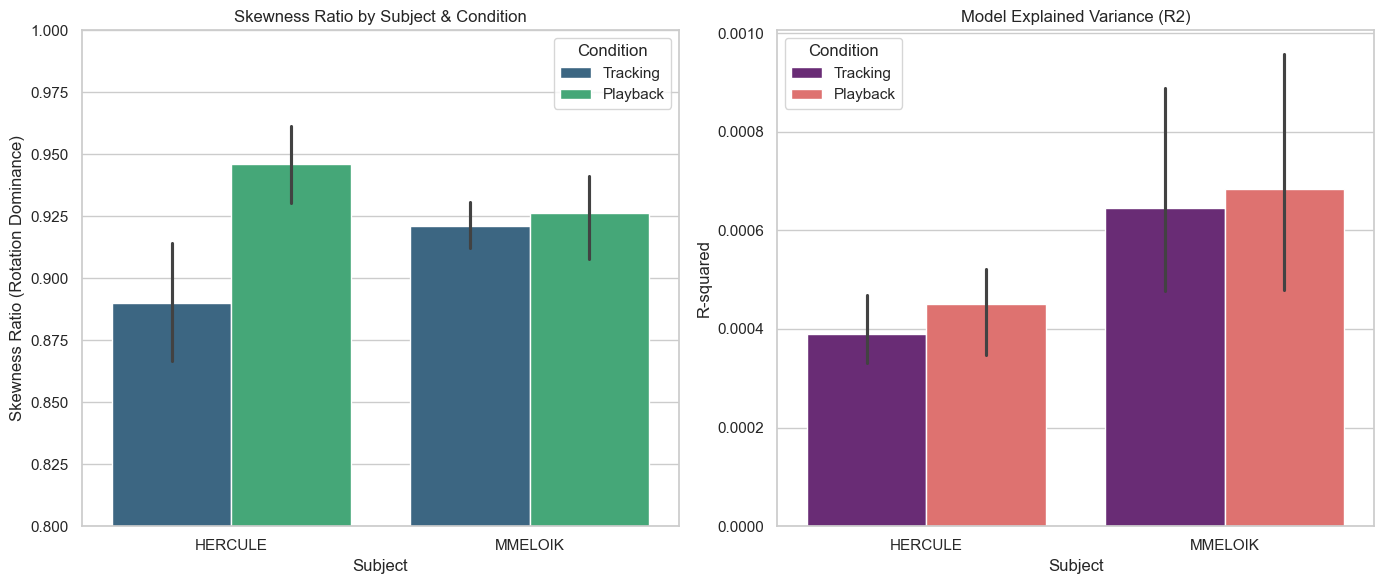

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置绘图风格
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. 绘制 Skewness Ratio 对比
sns.barplot(data=results_df, x='Subject', y='Skewness_Ratio', hue='Condition', ax=axes[0], palette='viridis')
axes[0].set_title('Skewness Ratio by Subject & Condition')
axes[0].set_ylim(0.8, 1.0) # 聚焦在高值区域
axes[0].set_ylabel('Skewness Ratio (Rotation Dominance)')

# 2. 绘制 R2 对比
sns.barplot(data=results_df, x='Subject', y='R2', hue='Condition', ax=axes[1], palette='magma')
axes[1].set_title('Model Explained Variance (R2)')
axes[1].set_ylabel('R-squared')

plt.tight_layout()
plt.show()

# <a id='toc2_'></a>[Rotational Manifold (CEBRA)](#toc0_)

## <a id='toc2_1_'></a>[Raw Space](#toc0_)

In [6]:
import torch
import gc
import cebra
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==========================================
# 1. 潜空间动力学拟合函数 (适配 z 空间)
# ==========================================
def fit_latent_generator(z, x_dot, dt=0.005):
    """
    在 CEBRA 降维后的潜空间 z (Time, 3) 上拟合旋转动力学
    """
    # 逻辑与之前的 fit_lie_algebra_with_leak 一致
    T, Dim = z.shape
    dz_dt = np.gradient(z, dt, axis=0) 
    
    U_rot = z * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, z]) 
    
    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dz_dt, rcond=None)
    weights = weights_T.T 
    
    J_unconstrained = weights[:, :Dim]
    L_leak = weights[:, Dim:]
    J_skew = 0.5 * (J_unconstrained - J_unconstrained.T)
    
    norm_total = np.linalg.norm(J_unconstrained)
    norm_skew = np.linalg.norm(J_skew)
    lat_skew_ratio = norm_skew / (norm_total + 1e-9)
    
    dz_dt_pred = U_rot @ J_skew.T + z @ L_leak.T
    from sklearn.metrics import r2_score
    lat_r2 = r2_score(dz_dt.flatten(), dz_dt_pred.flatten())
    
    return lat_skew_ratio, lat_r2

# ==========================================
# 2. 遍历个体与 Session 执行 CEBRA
# ==========================================
cebra_results_list = []

for subject in n_data_grouped.keys():
    print(f"\n🧠 Processing CEBRA for Subject: {subject}")
    
    # 获取该个体的所有数据
    subject_sessions_n = n_data_grouped[subject]
    subject_sessions_f = f_data_grouped[subject]
    
    for idx, (n_data_session, f_df) in enumerate(zip(subject_sessions_n, subject_sessions_f)):
        print(f"  - Training Session {idx}...")
        
        # --- A. 显存清理 ---
        gc.collect()
        torch.cuda.empty_cache()
        
        # --- B. 数据准备 ---
        # CEBRA 输入通常为 (Time, Neurons)
        r_data = n_data_session.T.astype(np.float32)
        x_dot_data = f_df['Speed_x'].values.astype(np.float32)
        conditions = f_df['Condition'].values
        
        # --- C. 构建并训练模型 ---
        model = cebra.CEBRA(
            model_architecture='offset10-model',
            output_dimension=3,
            batch_size=512,        # 限制 batch 大小防止 5070 Ti OOM
            max_iterations=1000,   # 为了速度先设为 1000，稳定后可改为 2000
            distance='cosine',
            conditional='time_delta',
            device='cuda'
        )
        
        try:
            # 训练并变换
            model.fit(r_data, x_dot_data)
            z = model.transform(r_data)
            
            # --- 修改这里的打印逻辑 ---
            print(f"    ✅ Session {idx} Training Done. Evaluating Dynamics:")
            
            for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
                mask = (conditions == val)
                if np.sum(mask) < 500: 
                    print(f"      - [{label}]: Data too short, skipping.")
                    continue
                
                z_sub = z[mask]
                x_dot_sub = x_dot_data[mask]
                
                lat_skew, lat_r2 = fit_latent_generator(z_sub, x_dot_sub)
                
                # 在这里打印，就能看到每一个条件的实时结果
                print(f"      - [{label}] Latent R2: {lat_r2:.4f}, Skew: {lat_skew:.2%}")
                
                cebra_results_list.append({
                    'Subject': subject,
                    'Session_Idx': idx,
                    'Condition': label,
                    'Latent_Skewness': lat_skew,
                    'Latent_R2': lat_r2
                })
            
        except Exception as e:
            print(f"    ❌ Error in Session {idx}: {e}")

# ==========================================
# 3. 结果汇总
# ==========================================
cebra_df = pd.DataFrame(cebra_results_list)
print("\n--- Raw Space CEBRA Latent Analysis Summary ---")
print(cebra_df.groupby(['Subject', 'Condition'])[['Latent_Skewness', 'Latent_R2']].mean())


🧠 Processing CEBRA for Subject: HERCULE
  - Training Session 0...
    ✅ Session 0 Training Done. Evaluating Dynamics:
      - [Tracking] Latent R2: 0.0035, Skew: 91.31%
      - [Playback] Latent R2: 0.0039, Skew: 93.20%
  - Training Session 1...
    ✅ Session 1 Training Done. Evaluating Dynamics:
      - [Tracking] Latent R2: 0.0047, Skew: 96.27%
      - [Playback] Latent R2: 0.0047, Skew: 98.60%
  - Training Session 2...
    ✅ Session 2 Training Done. Evaluating Dynamics:
      - [Tracking] Latent R2: 0.0043, Skew: 94.79%
      - [Playback] Latent R2: 0.0052, Skew: 96.83%
  - Training Session 3...
    ✅ Session 3 Training Done. Evaluating Dynamics:
      - [Tracking] Latent R2: 0.0004, Skew: 86.03%
      - [Playback]: Data too short, skipping.
  - Training Session 4...
    ✅ Session 4 Training Done. Evaluating Dynamics:
      - [Tracking] Latent R2: 0.0005, Skew: 78.94%
      - [Playback] Latent R2: 0.0005, Skew: 73.83%

🧠 Processing CEBRA for Subject: NAPOLEON

🧠 Processing CEBRA fo

In [7]:
import gc
import torch
import numpy as np
import pandas as pd
import cebra
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

# ==========================================
# 1. 核心算法：潜空间动力学拟合 (保持用户逻辑)
# ==========================================
def fit_latent_generator(embedding, x_dot, dt=0.005):
    T, N = embedding.shape
    dz_dt = np.gradient(embedding, dt, axis=0) 
    
    U_rot = embedding * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, embedding])
    
    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dz_dt, rcond=None)
    J_latent = weights_T.T[:, :N]
    L_leak = weights_T.T[:, N:]
    
    dz_dt_pred = U_rot @ J_latent.T + embedding @ L_leak.T
    r2 = r2_score(dz_dt.flatten(), dz_dt_pred.flatten())
    
    J_skew = 0.5 * (J_latent - J_latent.T)
    denom = np.linalg.norm(J_latent)
    skewness = np.linalg.norm(J_skew) / denom if denom > 1e-9 else 0
    
    return J_latent, skewness, r2

# ==========================================
# 2. 自动化批处理循环
# ==========================================
all_cebra_results = []

for subject in n_data_grouped.keys():
    print(f"\n" + "█" * 60)
    print(f"🚀 Processing Subject: {subject}")
    print("█" * 60)
    
    subject_n_list = n_data_grouped[subject]
    subject_f_list = f_data_grouped[subject]
    
    for idx, (n_raw, f_df) in enumerate(zip(subject_n_list, subject_f_list)):
        print(f"\n--- Session {idx} | Training CEBRA (Guided by Position) ---")
        
        # A. 显存清理
        gc.collect()
        torch.cuda.empty_cache()
        
        # B. 数据准备
        r_data = n_raw.T.astype(np.float32)
        pos_data = f_df['Position'].values.astype(np.float32)
        x_dot_data = f_df['Speed_x'].values.astype(np.float32)
        conditions = f_df['Condition'].values
        
        # C. CEBRA 降维
        model = cebra.CEBRA(
            model_architecture='offset10-model',
            output_dimension=3,
            batch_size=512,
            max_iterations=2000,
            distance='cosine',
            conditional='time_delta',
            device='cuda'
        )
        
        try:
            # 使用行为位置引导流形生成
            model.fit(r_data, pos_data)
            z = model.transform(r_data)
            
            # D. 高斯平滑 (魔咒破解器)
            z_smooth = gaussian_filter1d(z, sigma=5, axis=0)
            
            # E. 分 Condition 拟合动力学
            for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
                mask = (conditions == val)
                if np.sum(mask) < 500: continue
                
                z_sub = z_smooth[mask]
                x_dot_sub = x_dot_data[mask]
                
                # 拟合李代数
                J_lat, lat_skew, lat_r2 = fit_latent_generator(z_sub, x_dot_sub)
                
                print(f"  [{label}] R²: {lat_r2:.4f} | Skewness: {lat_skew:.2%}")
                
                all_cebra_results.append({
                    'Subject': subject,
                    'Session_Idx': idx,
                    'Condition': label,
                    'Skewness': lat_skew,
                    'R2': lat_r2,
                    'J_Matrix': J_lat
                })
                
        except Exception as e:
            print(f"  ❌ Error in Session {idx}: {e}")

# ==========================================
# 3. 统计汇总
# ==========================================
final_df = pd.DataFrame(all_cebra_results)
print("\n" + "=" * 45)
print("📊 FINAL TOPOLOGY-GUIDED SUMMARY")
print("=" * 45)
summary = final_df.groupby(['Subject', 'Condition'])[['R2', 'Skewness']].mean()
print(summary)


████████████████████████████████████████████████████████████
🚀 Processing Subject: HERCULE
████████████████████████████████████████████████████████████

--- Session 0 | Training CEBRA (Guided by Position) ---
  [Tracking] R²: 0.0035 | Skewness: 47.97%
  [Playback] R²: 0.0017 | Skewness: 87.15%

--- Session 1 | Training CEBRA (Guided by Position) ---
  [Tracking] R²: 0.0008 | Skewness: 31.94%
  [Playback] R²: 0.0006 | Skewness: 68.83%

--- Session 2 | Training CEBRA (Guided by Position) ---
  [Tracking] R²: 0.0005 | Skewness: 34.35%
  [Playback] R²: 0.0003 | Skewness: 76.19%

--- Session 3 | Training CEBRA (Guided by Position) ---
  [Tracking] R²: 0.0005 | Skewness: 42.99%

--- Session 4 | Training CEBRA (Guided by Position) ---
  [Tracking] R²: 0.0003 | Skewness: 18.02%
  [Playback] R²: 0.0002 | Skewness: 77.06%

████████████████████████████████████████████████████████████
🚀 Processing Subject: NAPOLEON
████████████████████████████████████████████████████████████

████████████████████

In [8]:
import gc
import torch
import numpy as np
import pandas as pd
import cebra
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d

# ==========================================
# 1. 潜空间动力学拟合函数 
# ==========================================
def fit_latent_generator(embedding, x_dot, dt=0.005):
    T, N = embedding.shape
    dz_dt = np.gradient(embedding, dt, axis=0) 
    
    U_rot = embedding * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, embedding])
    
    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dz_dt, rcond=None)
    J_latent = weights_T.T[:, :N]
    L_leak = weights_T.T[:, N:]
    
    dz_dt_pred = U_rot @ J_latent.T + embedding @ L_leak.T
    r2 = r2_score(dz_dt.flatten(), dz_dt_pred.flatten())
    
    J_skew = 0.5 * (J_latent - J_latent.T)
    denom = np.linalg.norm(J_latent)
    skewness = np.linalg.norm(J_skew) / denom if denom > 1e-9 else 0
    
    return J_latent, skewness, r2

# ==========================================
# 2. 自动化批处理：加入 Frequency_changes 过滤
# ==========================================
dynamic_window_results = []

for subject in n_data_grouped.keys():
    print(f"\n" + "█" * 60)
    print(f"🎯 Focusing on Stimulus-Driven Dynamics: {subject}")
    print("█" * 60)
    
    sub_n_list = n_data_grouped[subject]
    sub_f_list = f_data_grouped[subject]
    
    for idx, (n_raw, f_df) in enumerate(zip(sub_n_list, sub_f_list)):
        print(f"\n--- Session {idx} ---")
        
        # 显存清理
        gc.collect()
        torch.cuda.empty_cache()
        
        # 数据准备
        r_data = n_raw.T.astype(np.float32)
        pos_data = f_df['Position'].values.astype(np.float32)
        x_dot_data = f_df['Speed_x'].values.astype(np.float32)
        
        # 提取条件和频率变化标志
        conditions = f_df['Condition'].values
        freq_changes = f_df['Frequency_changes'].values
        
        # CEBRA 降维 (基于 Position 引导流形)
        model = cebra.CEBRA(
            model_architecture='offset10-model',
            output_dimension=3,
            batch_size=512,
            max_iterations=2000,
            distance='cosine',
            conditional='time_delta',
            device='cuda'
        )
        
        try:
            model.fit(r_data, pos_data)
            z = model.transform(r_data)
            
            # 高斯平滑
            z_smooth = gaussian_filter1d(z, sigma=5, axis=0)
            
            # --- 核心：定义 4 种子状态进行精细对比 ---
            analysis_groups = [
                ('Tracking_All', conditions == 0.0),
                ('Tracking_Moving (Freq_Change=1)', (conditions == 0.0) & (freq_changes == 1)),
                ('Playback_All', conditions == 1.0),
                ('Playback_Moving (Freq_Change=1)', (conditions == 1.0) & (freq_changes == 1))
            ]
            
            for label, mask in analysis_groups:
                # 降低一点数据量阈值，因为 freq_changes == 1 的时间窗口会比较短
                if np.sum(mask) < 150: 
                    print(f"  [{label}] ⚠️ Data too short ({np.sum(mask)} pts), skipping.")
                    continue
                
                z_sub = z_smooth[mask]
                x_dot_sub = x_dot_data[mask]
                
                # 拟合动力学
                J_lat, lat_skew, lat_r2 = fit_latent_generator(z_sub, x_dot_sub)
                
                print(f"  [{label}] R²: {lat_r2:.4f} | Skewness: {lat_skew:.2%}")
                
                dynamic_window_results.append({
                    'Subject': subject,
                    'Session_Idx': idx,
                    'Analysis_Window': label,
                    'Points_Count': np.sum(mask),
                    'Skewness': lat_skew,
                    'R2': lat_r2
                })
                
        except Exception as e:
            print(f"  ❌ Error in Session {idx}: {e}")

# ==========================================
# 3. 数据汇总与透视
# ==========================================
focused_df = pd.DataFrame(dynamic_window_results)

print("\n" + "=" * 60)
print("📊 DYNAMIC WINDOW COMPARISON SUMMARY")
print("=" * 60)
# 使用透视表更直观地对比 All vs Moving
summary_pivot = pd.pivot_table(
    focused_df, 
    values=['R2', 'Skewness'], 
    index=['Subject'], 
    columns=['Analysis_Window'], 
    aggfunc='mean'
)
print(summary_pivot)


████████████████████████████████████████████████████████████
🎯 Focusing on Stimulus-Driven Dynamics: HERCULE
████████████████████████████████████████████████████████████

--- Session 0 ---
  [Tracking_All] R²: 0.0045 | Skewness: 25.57%
  [Tracking_Moving (Freq_Change=1)] R²: 0.0013 | Skewness: 78.65%
  [Playback_All] R²: 0.0019 | Skewness: 98.74%
  [Playback_Moving (Freq_Change=1)] R²: 0.0017 | Skewness: 66.39%

--- Session 1 ---
  [Tracking_All] R²: 0.0395 | Skewness: 72.76%
  [Tracking_Moving (Freq_Change=1)] R²: 0.0038 | Skewness: 80.68%
  [Playback_All] R²: 0.0366 | Skewness: 76.88%
  [Playback_Moving (Freq_Change=1)] R²: 0.0014 | Skewness: 73.96%

--- Session 2 ---
  [Tracking_All] R²: 0.0018 | Skewness: 35.85%
  [Tracking_Moving (Freq_Change=1)] R²: 0.0012 | Skewness: 55.25%
  [Playback_All] R²: 0.0018 | Skewness: 80.28%
  [Playback_Moving (Freq_Change=1)] R²: 0.0015 | Skewness: 25.61%

--- Session 3 ---
  [Tracking_All] R²: 0.0034 | Skewness: 39.57%
  [Tracking_Moving (Freq_Cha

### <a id='toc2_1_1_'></a>[Non Linear Lie Algebra](#toc0_)

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 非线性李代数拟合函数 (引入速度二次项)
# ==========================================
def fit_nonlinear_lie_algebra_normalized(r, x_dot, dt=0.005):
    """
    拟合方程: dr/dt = (x_dot * J1 + x_dot^2 * J2 + L) * r
    - J1: 线性主旋转生成元
    - J2: 非线性增益调制项 (捕捉速度饱和或二次效应)
    - L: 泄漏/偏移项
    """
    T, N = r.shape
    dr_dt = np.gradient(r, dt, axis=0)
    
    # 构建基础驱动项
    U1 = r * x_dot[:, np.newaxis]          # 线性驱动
    U2 = r * (x_dot**2)[:, np.newaxis]     # 二次非线性驱动
    U_augmented = np.hstack([U1, U2, r])
    
    # 最小二乘求解权重矩阵 W = [J1, J2, L]
    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt, rcond=None)
    W = weights_T.T
    
    J1 = W[:, :N]
    J2 = W[:, N:2*N]
    L  = W[:, 2*N:]
    
    # 计算预测值与 R2
    dr_dt_pred = U1 @ J1.T + U2 @ J2.T + r @ L.T
    r2 = r2_score(dr_dt.flatten(), dr_dt_pred.flatten())
    
    # 计算主生成元 J1 的偏斜度 (Skewness)
    J1_skew = 0.5 * (J1 - J1.T)
    norm_total = np.linalg.norm(J1)
    skew_ratio = np.linalg.norm(J1_skew) / (norm_total + 1e-9)
    
    return skew_ratio, r2

# ==========================================
# 2. 自动化批处理：非线性拟合
# ==========================================
print("🚀 启动: 分个体非线性李代数动力学分析 (引入二次速度调制)")
nonlinear_results = []

for subject in n_data_grouped.keys():
    print(f"\n🌀 正在处理个体: {subject}")
    
    sub_n = n_data_grouped[subject]
    sub_f = f_data_grouped[subject]
    
    for idx, (n_raw, f_df) in enumerate(zip(sub_n, sub_f)):
        try:
            r_matrix = n_raw.T.astype(np.float32)
            x_dot = f_df['Speed_x'].values.astype(np.float32)
            cond = f_df['Condition'].values
            
            # --- 核心预处理: L2 归一化 (投影到球面) ---
            norms = np.linalg.norm(r_matrix, axis=1, keepdims=True)
            r_n = r_matrix / (norms + 1e-9)
            
            # --- 按 Condition 拆分拟合 ---
            for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
                mask = (cond == val)
                if np.sum(mask) > 500:
                    r_sub = r_n[mask]
                    x_dot_sub = x_dot[mask]
                    
                    skew, r2 = fit_nonlinear_lie_algebra_normalized(r_sub, x_dot_sub)
                    
                    nonlinear_results.append({
                        'Subject': subject,
                        'Session': idx,
                        'Condition': label,
                        'NonLinear_Skewness': skew,
                        'NonLinear_R2': r2
                    })
                    
        except Exception as e:
            print(f"  ⚠️ Session {idx} 发生错误跳过: {e}")

# ==========================================
# 3. 结果透视与对比汇总
# ==========================================
df_nl = pd.DataFrame(nonlinear_results)

print("\n" + "="*60)
print("📊 非线性李代数拟合结果摘要 (Non-linear R² & Skewness)")
print("="*60)

# 1. 总体 R2 提升情况
mean_r2_tr = df_nl[df_nl['Condition']=='Tracking']['NonLinear_R2'].mean()
mean_r2_pb = df_nl[df_nl['Condition']=='Playback']['NonLinear_R2'].mean()
mean_skew_tr = df_nl[df_nl['Condition']=='Tracking']['NonLinear_Skewness'].mean()

print(f"➤ 全局均值 (Tracking): R² = {mean_r2_tr:.4f} | Skewness = {mean_skew_tr:.2%}")
print(f"➤ 全局均值 (Playback): R² = {mean_r2_pb:.4f}")
print("-" * 60)

# 2. 按个体的详细数据表
pivot_summary = df_nl.pivot_table(
    index='Subject', 
    columns='Condition', 
    values=['NonLinear_R2', 'NonLinear_Skewness'],
    aggfunc='mean'
)
print(pivot_summary.round(4))
print("="*60)

🚀 启动: 分个体非线性李代数动力学分析 (引入二次速度调制)

🌀 正在处理个体: HERCULE

🌀 正在处理个体: NAPOLEON

🌀 正在处理个体: MMELOIK

📊 非线性李代数拟合结果摘要 (Non-linear R² & Skewness)
➤ 全局均值 (Tracking): R² = 0.0006 | Skewness = 92.92%
➤ 全局均值 (Playback): R² = 0.0006
------------------------------------------------------------
          NonLinear_R2          NonLinear_Skewness         
Condition     Playback Tracking           Playback Tracking
Subject                                                    
HERCULE         0.0004   0.0004             0.9456   0.9272
MMELOIK         0.0006   0.0007             0.9268   0.9301


### <a id='toc2_1_2_'></a>[Deep Neural Lie Algebra](#toc0_)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 定义深度神经李代数网络 (Neural Lie Algebra)
# ==========================================
class NeuralLieGenerator(nn.Module):
    def __init__(self, N, hidden_dim=64):
        super(NeuralLieGenerator, self).__init__()
        self.N = N
        
        # MLP 网络：输入 (当前神经状态 r + 行为速度 x_dot) -> 输出 (矩阵元素)
        self.net = nn.Sequential(
            nn.Linear(N + 1, hidden_dim),
            nn.Tanh(), # 使用 Tanh 使得输出平滑
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, N * N)
        )
        
        # L 泄漏矩阵我们设为可学习的全局参数 (因为生物基础耗散通常是稳定的)
        self.L = nn.Parameter(torch.randn(N, N) * 0.01)

    def forward(self, r, x_dot):
        # r: [T, N], x_dot: [T, 1]
        inputs = torch.cat([r, x_dot], dim=-1) # [T, N+1]
        
        # 1. 神经网络预测动态矩阵 M_t
        M = self.net(inputs).view(-1, self.N, self.N) # [T, N, N]
        
        # 2. 强制对称化操作，生成动态的 反对称李代数矩阵 J_t
        J_skew = 0.5 * (M - M.transpose(1, 2)) # J = (M - M^T)/2
        
        # 3. 计算动力学导数: dr/dt = (x_dot * J_skew + L) * r
        # 使用批量矩阵乘法 (bmm)
        # J_skew * x_dot: [T, N, N]
        J_driven = J_skew * x_dot.unsqueeze(-1) 
        
        # 旋转驱动项: J_driven @ r
        rot_term = torch.bmm(J_driven, r.unsqueeze(-1)).squeeze(-1) # [T, N]
        
        # 泄漏项: r @ L^T
        leak_term = torch.matmul(r, self.L.t()) # [T, N]
        
        dr_dt_pred = rot_term + leak_term
        return dr_dt_pred, J_skew

# ==========================================
# 2. 训练与拟合函数
# ==========================================
def train_neural_lie_algebra(r_np, x_dot_np, dt=0.005, epochs=300, lr=1e-3, device='cuda'):
    T, N = r_np.shape
    
    # 真实导数
    dr_dt_np = np.gradient(r_np, dt, axis=0)
    
    # 转换为 Tensor
    r_t = torch.tensor(r_np, dtype=torch.float32).to(device)
    x_dot_t = torch.tensor(x_dot_np, dtype=torch.float32).unsqueeze(-1).to(device)
    dr_dt_t = torch.tensor(dr_dt_np, dtype=torch.float32).to(device)
    
    # 初始化模型与优化器
    model = NeuralLieGenerator(N=N).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    
    # 训练循环 (全批量梯度下降)
    for epoch in range(epochs):
        optimizer.zero_grad()
        dr_dt_pred, J_skew = model(r_t, x_dot_t)
        loss = criterion(dr_dt_pred, dr_dt_t)
        loss.backward()
        optimizer.step()
        
    # 提取最终结果计算 R2 和 Skewness
    model.eval()
    with torch.no_grad():
        dr_dt_pred, J_skew = model(r_t, x_dot_t)
        r2 = r2_score(dr_dt_np.flatten(), dr_dt_pred.cpu().numpy().flatten())
        
        # 计算整个时间序列上 J 矩阵强度的均值作为参考
        mean_J_norm = torch.norm(J_skew, dim=(1,2)).mean().item()
        
    return r2, mean_J_norm

# ==========================================
# 3. 自动化批处理
# ==========================================
print("🚀 启动: 深度神经李代数 (Neural Lie Algebra) 动态拟合...")
neural_results = []

for subject in n_data_grouped.keys():
    print(f"\n🧠 正在训练神经网络: {subject}")
    
    for idx, (n_raw, f_df) in enumerate(zip(n_data_grouped[subject], f_data_grouped[subject])):
        try:
            r_matrix = n_raw.T.astype(np.float32)
            x_dot = f_df['Speed_x'].values.astype(np.float32)
            cond = f_df['Condition'].values
            
            # L2 归一化
            norms = np.linalg.norm(r_matrix, axis=1, keepdims=True)
            r_n = r_matrix / (norms + 1e-9)
            
            for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
                mask = (cond == val)
                if np.sum(mask) > 500:
                    r_sub = r_n[mask]
                    x_dot_sub = x_dot[mask]
                    
                    # 运行神经网络拟合 (每个 Session 训练 300 轮)
                    r2, mean_J = train_neural_lie_algebra(r_sub, x_dot_sub, epochs=400)
                    
                    neural_results.append({
                        'Subject': subject,
                        'Session': idx,
                        'Condition': label,
                        'Neural_R2': r2,
                        'Mean_J_Intensity': mean_J
                    })
                    print(f"  ✅ {label} - Session {idx}: Neural R² = {r2:.4f}")
                    
        except Exception as e:
            print(f"  ⚠️ Session {idx} 发生错误: {e}")

# ==========================================
# 4. 结果汇总
# ==========================================
df_neural = pd.DataFrame(neural_results)

print("\n" + "="*60)
print("📊 深度神经李代数 拟合结果摘要 (Neural R²)")
print("="*60)
pivot_summary = df_neural.pivot_table(
    index='Subject', 
    columns='Condition', 
    values='Neural_R2',
    aggfunc='mean'
)
print(pivot_summary.round(4))
print("="*60)

🚀 启动: 深度神经李代数 (Neural Lie Algebra) 动态拟合...

🧠 正在训练神经网络: HERCULE
  ✅ Tracking - Session 0: Neural R² = 0.0018
  ✅ Playback - Session 0: Neural R² = 0.0021
  ✅ Tracking - Session 1: Neural R² = 0.0012
  ✅ Playback - Session 1: Neural R² = 0.0017
  ✅ Tracking - Session 2: Neural R² = 0.0018
  ✅ Playback - Session 2: Neural R² = 0.0019
  ✅ Tracking - Session 3: Neural R² = 0.0006
  ✅ Tracking - Session 4: Neural R² = 0.0013
  ✅ Playback - Session 4: Neural R² = 0.0018

🧠 正在训练神经网络: NAPOLEON

🧠 正在训练神经网络: MMELOIK
  ✅ Tracking - Session 0: Neural R² = 0.0026
  ✅ Playback - Session 0: Neural R² = 0.0026
  ✅ Tracking - Session 1: Neural R² = 0.0022
  ✅ Playback - Session 1: Neural R² = 0.0023
  ✅ Tracking - Session 2: Neural R² = 0.0026
  ✅ Playback - Session 2: Neural R² = 0.0025
  ✅ Tracking - Session 3: Neural R² = 0.0020
  ✅ Playback - Session 3: Neural R² = 0.0020
  ✅ Tracking - Session 4: Neural R² = 0.0022
  ✅ Playback - Session 4: Neural R² = 0.0019
  ✅ Tracking - Session 5: Neural R² = 

### <a id='toc2_1_3_'></a>[Event-Related Lie Algebra](#toc0_)


🌀 正在处理个体: HERCULE

🌀 正在处理个体: NAPOLEON

🌀 正在处理个体: MMELOIK


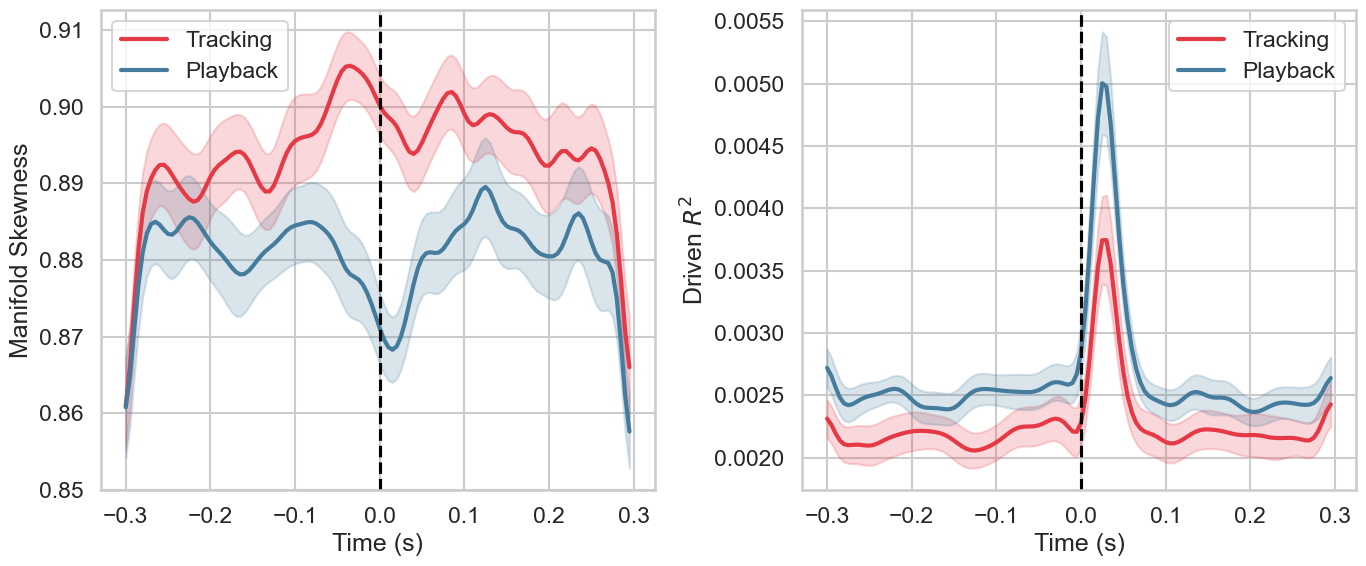

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import r2_score

# ==========================================
# 0. 基础拟合函数 (支持局部窗口拟合)
# ==========================================
def fit_lie_algebra_instantaneous_with_r2(r_trials, x_dot_trials, dr_dt_trials):
    n_samples, N = r_trials.shape
    U_rot = r_trials * x_dot_trials[:, np.newaxis]
    U_augmented = np.hstack([U_rot, r_trials]) 
    
    try:
        weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt_trials, rcond=None)
        weights = weights_T.T
        J_unconstrained = weights[:, :N]
        L_leak = weights[:, N:]
        J_skew = 0.5 * (J_unconstrained - J_unconstrained.T)
        
        norm_total = np.linalg.norm(J_unconstrained)
        skew_ratio = np.linalg.norm(J_skew) / (norm_total + 1e-9)
        
        dr_dt_pred = U_rot @ J_skew.T + r_trials @ L_leak.T
        r2 = r2_score(dr_dt_trials.flatten(), dr_dt_pred.flatten())
        
        return skew_ratio, r2
    except:
        return np.nan, np.nan

# ==========================================
# 1. 最终分析函数 (修正变量名 r_mat & 对齐检查)
# ==========================================
def run_event_related_analysis_final(n_dict, f_dict, pre_sec=0.3, post_sec=0.3, dt=0.005):
    pre_frames = int(pre_sec / dt)
    post_frames = int(post_sec / dt)
    # 确保 time_axis 长度一致
    total_frames = pre_frames + post_frames
    time_axis = np.arange(-pre_frames, post_frames) * dt
    
    temporal_dynamics = {'Tracking': {'skew': [], 'r2': []}, 
                         'Playback': {'skew': [], 'r2': []}}

    for subject in n_dict.keys():
        print(f"\n🌀 正在处理个体: {subject}")
        for sess_idx in range(len(n_dict[subject])):
            n_raw = n_dict[subject][sess_idx]
            f_df = f_dict[subject][sess_idx]
            
            r_mat = n_raw.T.astype(np.float32)
            n_neurons = r_mat.shape[1]
            x_dot = f_df['Speed_x'].values.astype(np.float32)
            cond = f_df['Condition'].values
            freq_change = f_df['Frequency_changes'].values
            
            # L2 归一化
            r_n = r_mat / (np.linalg.norm(r_mat, axis=1, keepdims=True) + 1e-9)
            dr_dt_matrix = np.gradient(r_n, dt, axis=0)
            
            for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
                # 💡 修正点：使用当前 session 的长度 len(r_n)
                t0_indices = np.where((cond == val) & (freq_change == 1))[0]
                t0_indices = [i for i in t0_indices if i >= pre_frames and i + post_frames < len(r_n)]
                
                if len(t0_indices) < 10: continue
                
                # 使用 np.stack 强制生成 (Trials, Time, Neurons) 的 3D 数组
                try:
                    r_epochs = np.stack([r_n[i - pre_frames : i + post_frames] for i in t0_indices])
                    x_epochs = np.stack([x_dot[i - pre_frames : i + post_frames] for i in t0_indices])
                    dr_epochs = np.stack([dr_dt_matrix[i - pre_frames : i + post_frames] for i in t0_indices])
                except ValueError:
                    continue # 如果切片长度不一，跳过该 Session
                
                session_skew, session_r2 = [], []
                
                for t in range(len(time_axis)):
                    t_start, t_end = max(0, t-2), min(total_frames, t+3)
                    
                    # 💡 修正点：使用局部神经元数量 n_neurons
                    r_t = r_epochs[:, t_start:t_end, :].reshape(-1, n_neurons)
                    x_t = x_epochs[:, t_start:t_end].flatten()
                    dr_t = dr_epochs[:, t_start:t_end, :].reshape(-1, n_neurons)
                    
                    skew, r2 = fit_lie_algebra_instantaneous_with_r2(r_t, x_t, dr_t)
                    session_skew.append(skew)
                    session_r2.append(r2)
                    
                temporal_dynamics[label]['skew'].append(session_skew)
                temporal_dynamics[label]['r2'].append(session_r2)
                
    return temporal_dynamics, time_axis

# --- 执行分析 ---
time_dyn, time_axis = run_event_related_analysis_final(n_data_grouped, f_data_grouped)

# ==========================================
# 2. 绘图与统计 (与之前逻辑一致)
# ==========================================
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid", context="talk")
metrics = [('skew', 'Manifold Skewness'), ('r2', 'Driven $R^2$')]
colors = {'Tracking': '#E63946', 'Playback': '#457B9D'}

for i, (m_key, ylabel) in enumerate(metrics):
    plt.subplot(1, 2, i+1)
    for label in ['Tracking', 'Playback']:
        if not time_dyn[label][m_key]: continue
        data = np.array(time_dyn[label][m_key])
        m_curve = gaussian_filter1d(np.nanmean(data, axis=0), sigma=2)
        s_curve = gaussian_filter1d(np.nanstd(data, axis=0)/np.sqrt(len(data)), sigma=2)
        
        plt.plot(time_axis, m_curve, color=colors[label], lw=3, label=label)
        plt.fill_between(time_axis, m_curve-s_curve, m_curve+s_curve, color=colors[label], alpha=0.2)
    
    plt.axvline(0, color='black', ls='--')
    plt.xlabel('Time (s)')
    plt.ylabel(ylabel)
    plt.legend()

plt.tight_layout()
plt.show()

confound: trigger (space in time) filter triggers without neighbours -.2s

🌀 正在处理个体: HERCULE
🌀 正在处理个体: NAPOLEON
🌀 正在处理个体: MMELOIK


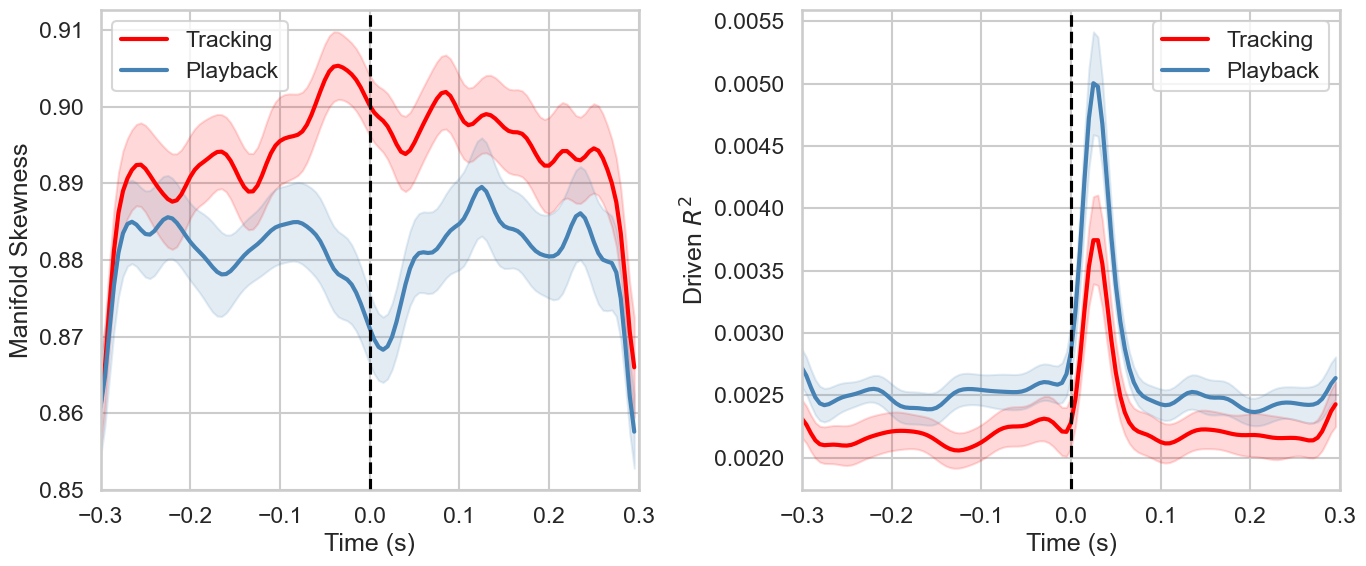


📊 各个体 & Session 详细统计记录 (刺激后 0-200ms 均值)
Condition        Playback  Tracking  Diff (TR-PB)
Subject Session                                  
HERCULE 0          0.8954    0.9265        0.0311
        1          0.9074    0.9002       -0.0072
        2          0.9003    0.9032        0.0029
        4          0.8922    0.8928        0.0006
MMELOIK 0          0.8655    0.8964        0.0310
        1          0.8517    0.8737        0.0220
        2          0.8521    0.8624        0.0103
        3          0.8704    0.8921        0.0217
        4          0.8652    0.8838        0.0186
        5          0.8616    0.8748        0.0132
        6          0.8829    0.9207        0.0377
        7          0.8987    0.9075        0.0088
        8          0.8930    0.9047        0.0118
        9          0.8954    0.9184        0.0230
        10         0.8792    0.8941        0.0149
        11         0.8819    0.8965        0.0145
-----------------------------------------------------------

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import r2_score

# ==========================================
# 0. 基础拟合函数 (支持局部窗口 & R2)
# ==========================================
def fit_lie_algebra_instantaneous_with_r2(r_t, x_t, dr_dt_t):
    n_samples, N = r_t.shape
    U_rot = r_t * x_t[:, np.newaxis]
    U_aug = np.hstack([U_rot, r_t]) 
    try:
        weights_T, _, _, _ = np.linalg.lstsq(U_aug, dr_dt_t, rcond=None)
        weights = weights_T.T
        J = weights[:, :N]
        L = weights[:, N:]
        J_skew = 0.5 * (J - J.T)
        skew = np.linalg.norm(J_skew) / (np.linalg.norm(J) + 1e-9)
        # 计算针对反对称旋转项的解释力 R2
        dr_dt_pred = U_rot @ J_skew.T + r_t @ L.T
        r2 = r2_score(dr_dt_t.flatten(), dr_dt_pred.flatten())
        return skew, r2
    except:
        return np.nan, np.nan

# ==========================================
# 1. 核心分析：提取 Epoch 并进行跨 Trial 局部窗口拟合
# ==========================================
def run_event_related_analysis_final(n_dict, f_dict, pre_sec=0.3, post_sec=0.3, dt=0.005):
    pre_f, post_f = int(pre_sec / dt), int(post_sec / dt)
    time_axis = np.arange(-pre_f, post_f) * dt
    
    # 存储用于绘图的群体数据
    pop_dyn = {'Tracking': {'skew': [], 'r2': []}, 'Playback': {'skew': [], 'r2': []}}
    # 存储用于详细统计的 Session-wise 数据 (取刺激后 0-200ms 的均值)
    session_stats = []

    for subj in n_dict.keys():
        print(f"🌀 正在处理个体: {subj}")
        for s_idx, (n_raw, f_df) in enumerate(zip(n_dict[subj], f_dict[subj])):
            r_mat = n_raw.T.astype(np.float32)
            N = r_mat.shape[1]
            x_dot = f_df['Speed_x'].values.astype(np.float32)
            cond, f_change = f_df['Condition'].values, f_df['Frequency_changes'].values
            
            r_n = r_mat / (np.linalg.norm(r_mat, axis=1, keepdims=True) + 1e-9)
            dr_dt_mat = np.gradient(r_n, dt, axis=0)
            
            for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
                t0s = np.where((cond == val) & (f_change == 1))[0]
                t0s = [i for i in t0s if i >= pre_f and i + post_f < len(r_n)]
                if len(t0s) < 8: continue
                
                # 提取并对齐试次
                r_eps = np.stack([r_n[i-pre_f : i+post_f] for i in t0s])
                x_eps = np.stack([x_dot[i-pre_f : i+post_f] for i in t0s])
                dr_eps = np.stack([dr_dt_mat[i-pre_f : i+post_f] for i in t0s])
                
                s_skew, s_r2 = [], []
                for t in range(len(time_axis)):
                    # 滑动窗口平滑拟合 (t-2 to t+2)
                    ts, te = max(0, t-2), min(len(time_axis), t+3)
                    rt = r_eps[:, ts:te, :].reshape(-1, N)
                    xt = x_eps[:, ts:te].flatten()
                    drt = dr_eps[:, ts:te, :].reshape(-1, N)
                    
                    sk, r2 = fit_lie_algebra_instantaneous_with_r2(rt, xt, drt)
                    s_skew.append(sk); s_r2.append(r2)
                
                pop_dyn[label]['skew'].append(s_skew)
                pop_dyn[label]['r2'].append(s_r2)
                
                # 记录该 Session 在响应窗口 (0-200ms) 的表现
                resp_mask = (time_axis >= 0) & (time_axis <= 0.2)
                session_stats.append({
                    'Subject': subj, 'Session': s_idx, 'Condition': label,
                    'Avg_Skew': np.nanmean(np.array(s_skew)[resp_mask]),
                    'Avg_R2': np.nanmean(np.array(s_r2)[resp_mask])
                })
                
    return pop_dyn, pd.DataFrame(session_stats), time_axis

# --- 执行分析 ---
pop_dyn, df_sess, time_axis = run_event_related_analysis_final(n_data_grouped, f_data_grouped)

# ==========================================
# 2. 绘图部分 (Plotting)
# ==========================================
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid", context="talk")
for i, (m_key, ylabel) in enumerate([('skew', 'Manifold Skewness'), ('r2', 'Driven $R^2$')]):
    plt.subplot(1, 2, i+1)
    for label in ['Tracking', 'Playback']:
        data = np.array(pop_dyn[label][m_key])
        m_curve = gaussian_filter1d(np.nanmean(data, axis=0), sigma=2)
        s_curve = gaussian_filter1d(np.nanstd(data, axis=0)/np.sqrt(len(data)), sigma=2)
        plt.plot(time_axis, m_curve, color='red' if label=='Tracking' else 'steelblue', lw=3, label=label)
        plt.fill_between(time_axis, m_curve-s_curve, m_curve+s_curve, alpha=0.15, color='red' if label=='Tracking' else 'steelblue')
    plt.axvline(0, color='black', ls='--'); plt.xlim(-0.3, 0.3)
    plt.xlabel('Time (s)'); plt.ylabel(ylabel); plt.legend()
plt.tight_layout(); plt.show()

# ==========================================
# 3. 统计输出与显著性检验 (Detailed Report)
# ==========================================
print("\n" + "="*65)
print("📊 各个体 & Session 详细统计记录 (刺激后 0-200ms 均值)")
print("="*65)

# 转换成配对格式表格 (以 Skewness 为例)
pivot_stats = df_sess.pivot_table(index=['Subject', 'Session'], columns='Condition', values='Avg_Skew').dropna()
pivot_stats['Diff (TR-PB)'] = pivot_stats['Tracking'] - pivot_stats['Playback']

print(pivot_stats.round(4).sort_index())
print("-" * 65)

# 执行配对 Wilcoxon 检验
stat, p_val = wilcoxon(pivot_stats['Tracking'], pivot_stats['Playback'])
mean_tr, mean_pb = pivot_stats['Tracking'].mean(), pivot_stats['Playback'].mean()
improve = (mean_tr - mean_pb) / mean_pb * 100

print(f"⚖️ 统计显著性报告 (N = {len(pivot_stats)} Sessions):")
print(f"   ↳ 响应期 Skewness 差异 P-value: {p_val:.4e}")
print(f"   ↳ Tracking 相比 Playback 旋转纯度提升了: {mean_tr-mean_pb:.4f} ({improve:+.1f}%)")

if p_val < 0.05:
    print("   ✅ 结论：显著！主动追踪显著增强了刺激诱发的流形旋转纯度。")
else:
    print("   ⚠️ 结论：不显著。两种状态下的流形几何特征在统计上没有差异。")

### <a id='toc2_1_4_'></a>[Ablation Study](#toc0_)

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from tqdm import tqdm

# ==========================================
# 1. 核心算法：带 Leak 项的生成元拟合 (适配归一化空间)
# ==========================================
def fit_lie_algebra_normalized(r, x_dot, dt=0.005):
    """
    拟合公式: dr/dt = (x_dot * J_skew + L_leak) * r
    r 已经过 L2 归一化，位于单位球面上
    """
    T, N = r.shape
    # 计算切向速度 (速度矢量现在只代表方向的变化)
    dr_dt = np.gradient(r, dt, axis=0) 
    
    # 构建增强矩阵 [旋转驱动项, 衰减/偏移项]
    U_rot = r * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, r]) 
    
    # 最小二乘求解
    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt, rcond=None)
    weights = weights_T.T # (N, 2N)
    
    J_unconstrained = weights[:, :N]
    L_leak = weights[:, N:]
    
    # 提取纯旋转分量 (反对称矩阵)
    J_skew = 0.5 * (J_unconstrained - J_unconstrained.T)
    
    # 计算指标
    norm_total = np.linalg.norm(J_unconstrained)
    norm_skew = np.linalg.norm(J_skew)
    skewness_ratio = norm_skew / (norm_total + 1e-9)
    
    # 计算预测值与 R2
    dr_dt_pred = U_rot @ J_skew.T + r @ L_leak.T
    r2 = r2_score(dr_dt.flatten(), dr_dt_pred.flatten())
    
    return skewness_ratio, r2

# ==========================================
# 2. 自动化批处理：剥离 Magnitude 分析
# ==========================================
normalization_results = []

for subject in n_data_grouped.keys():
    print(f"🌟 Analyzing Pure Directional Dynamics: {subject}")
    
    sub_n_list = n_data_grouped[subject]
    sub_f_list = f_data_grouped[subject]
    
    for idx, (n_raw, f_df) in enumerate(zip(sub_n_list, sub_f_list)):
        # 转置为 (Time, Neurons)
        r_matrix = n_raw.T 
        x_dot_data = f_df['Speed_x'].values
        conditions = f_df['Condition'].values
        
        # --- 核心消融操作：L2 Normalization ---
        # 计算每一时刻的群体矢量长度
        norms = np.linalg.norm(r_matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1e-9 # 避免除零
        r_normalized = r_matrix / norms # 投影到单位球面
        
        # 分条件进行拟合
        for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
            mask = (conditions == val)
            if np.sum(mask) < 500: continue
            
            r_sub = r_normalized[mask]
            x_dot_sub = x_dot_data[mask]
            
            try:
                skew_ratio, r2 = fit_lie_algebra_normalized(r_sub, x_dot_sub)
                
                normalization_results.append({
                    'Subject': subject,
                    'Session_Idx': idx,
                    'Condition': label,
                    'Pure_Skewness': skew_ratio,
                    'Pure_R2': r2
                })
            except Exception as e:
                print(f"  Error in {subject} Session {idx}: {e}")

# ==========================================
# 3. 汇总与对比
# ==========================================
norm_df = pd.DataFrame(normalization_results)

print("\n" + "="*50)
print("📊 ABLATION STUDY: PURE DIRECTIONAL DYNAMICS")
print("="*50)
summary = norm_df.groupby(['Subject', 'Condition'])[['Pure_Skewness', 'Pure_R2']].mean()
print(summary)

🌟 Analyzing Pure Directional Dynamics: HERCULE
🌟 Analyzing Pure Directional Dynamics: NAPOLEON
🌟 Analyzing Pure Directional Dynamics: MMELOIK

📊 ABLATION STUDY: PURE DIRECTIONAL DYNAMICS
                   Pure_Skewness   Pure_R2
Subject Condition                         
HERCULE Playback        0.968981  0.000320
        Tracking        0.923957  0.000297
MMELOIK Playback        0.938969  0.000544
        Tracking        0.940628  0.000541


In [14]:
import gc
import torch
import numpy as np
import pandas as pd
import cebra
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d

# ==========================================
# 1. 拟合函数 (保持不变，支持 L 矩阵吸收对称方差)
# ==========================================
def fit_latent_generator(embedding, x_dot, dt=0.005):
    T, N = embedding.shape
    dz_dt = np.gradient(embedding, dt, axis=0) 
    U_rot = embedding * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, embedding])
    
    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dz_dt, rcond=None)
    J_latent = weights_T.T[:, :N]
    L_leak = weights_T.T[:, N:]
    
    dz_dt_pred = U_rot @ J_latent.T + embedding @ L_leak.T
    r2 = r2_score(dz_dt.flatten(), dz_dt_pred.flatten())
    
    J_skew = 0.5 * (J_latent - J_latent.T)
    skewness = np.linalg.norm(J_skew) / np.linalg.norm(J_latent)
    
    return J_latent, skewness, r2

# ==========================================
# 2. 数据准备与归一化
# ==========================================
gc.collect()
torch.cuda.empty_cache()

session_idx = 0 
r_matrix_raw = n_data_s[session_idx].T
f_df = f_data_s[session_idx]
pos_array = f_df['Position'].values
x_dot_array = f_df['Speed_x'].values
conditions = f_df['Condition'].values

# 🌟 执行归一化消融：只保留方向信息
norms = np.linalg.norm(r_matrix_raw, axis=1, keepdims=True)
norms[norms == 0] = 1e-9
r_norm = (r_matrix_raw / norms).astype(np.float32)

# ==========================================
# 3. 训练共享流形 (确保坐标系一致)
# ==========================================
print("🚀 正在训练共享流形...")
model = cebra.CEBRA(
    model_architecture='offset10-model',
    output_dimension=3,
    batch_size=512,
    max_iterations=2000,
    distance='cosine',
    conditional='time_delta',
    device='cuda'
)
model.fit(r_norm, pos_array.astype(np.float32))
z = model.transform(r_norm)
z_smooth = gaussian_filter1d(z, sigma=5, axis=0)

# ==========================================
# 4. 条件拆分拟合
# ==========================================
results = []
print("\n" + "=" * 50)
print(f"✅ Session {session_idx} | Latent Dynamics Split Analysis")
print("=" * 50)

for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
    mask = (conditions == val)
    if np.sum(mask) < 500: continue
    
    # 提取对应条件的潜空间轨迹和速度
    z_sub = z_smooth[mask]
    x_dot_sub = x_dot_array[mask]
    
    # 拟合
    J_lat, lat_skew, lat_r2 = fit_latent_generator(z_sub, x_dot_sub)
    
    print(f"[{label} Mode]")
    print(f"🌟 Skewness Ratio : {lat_skew:.2%}")
    print(f"🌟 R² Score       : {lat_r2:.4f}")
    print("-" * 30)

print("=" * 50)

NameError: name 'n_data_s' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# 1. 把 CEBRA 的 3D 环投影到最主要的 2D 平面上 (寻找最佳的正圆视角)
pca = PCA(n_components=2)
# 注意我们要把中心对齐到原点，才能算角度
z_centered = z_smooth - np.mean(z_smooth, axis=0)
z_2d = pca.fit_transform(z_centered)

# 2. 提取神经流形的“内在相位” (Angle / Phase)
# 使用 arctan2 计算每个时间点在环上的角度，范围 [-pi, pi]
neural_phase = np.arctan2(z_2d[:, 1], z_2d[:, 0])

# 3. 解卷绕 (Unwrap)：防止角度从 pi 突然跳到 -pi 产生的巨大人工导数
neural_phase_unwrapped = np.unwrap(neural_phase)

# 4. 计算内在相位的角速度 (Neural Angular Velocity)
# 这一步对应你的方程左边：真正的状态变化率
d_theta_dt = np.gradient(neural_phase_unwrapped, 0.005)

# 5. 终极对决：流形角速度 vs 物理真实速度
# 因为我们不知道物理速度和流形相位的单位比例，我们计算皮尔逊相关系数
correlation, p_value = pearsonr(d_theta_dt, x_dot_data)

# --- 画图展示这个震撼的结果 ---
plt.figure(figsize=(10, 4))
time_axis = np.arange(2000) * 0.005 # 画前 10 秒的局部细节

# 对物理速度做一点缩放，只是为了能在同一张图里对齐显示趋势
scale_factor = np.std(d_theta_dt) / (np.std(x_dot_data) + 1e-9)

plt.plot(time_axis, d_theta_dt[:2000], label='Neural Manifold Angular Velocity ($\dot{\theta}$)', color='red', alpha=0.8)
plt.plot(time_axis, x_dot_data[:2000] * scale_factor, label='Physical Head Speed ($\dot{x}$)', color='black', alpha=0.6, linestyle='--')

plt.title(f'Continuous Attractor Validation\nPearson Correlation: {correlation:.4f} (p={p_value:.2e})', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (Normalized for visualization)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"🌟 神经流形角速度与物理速度的相关性 (Pearson r): {correlation:.4f}")

In [ ]:
# 引入 Leak 项的升级版回归
U_augmented = np.hstack([r_matrix * x_dot_array[:, np.newaxis], r_matrix])
J_augmented_T, _, _, _ = np.linalg.lstsq(U_augmented, np.gradient(r_matrix, 0.005, axis=0), rcond=None)

# 提取 J 和 leak
J_new = J_augmented_T.T[:, :14]  # 前 14 列是 J
Leak_matrix = J_augmented_T.T[:, 14:] # 后面是 Leak

# 重新计算反对称性
J_skew_new = 0.5 * (J_new - J_new.T)
print(f"引入 Leak 后，J 矩阵的反对称比例: {np.linalg.norm(J_skew_new, ord='fro') / np.linalg.norm(J_new, ord='fro'):.2%}")

## <a id='toc2_2_'></a>[Heatmap](#toc0_)


🔥 Visualizing J Matrix: Subject [MMELOIK] | Session [3]


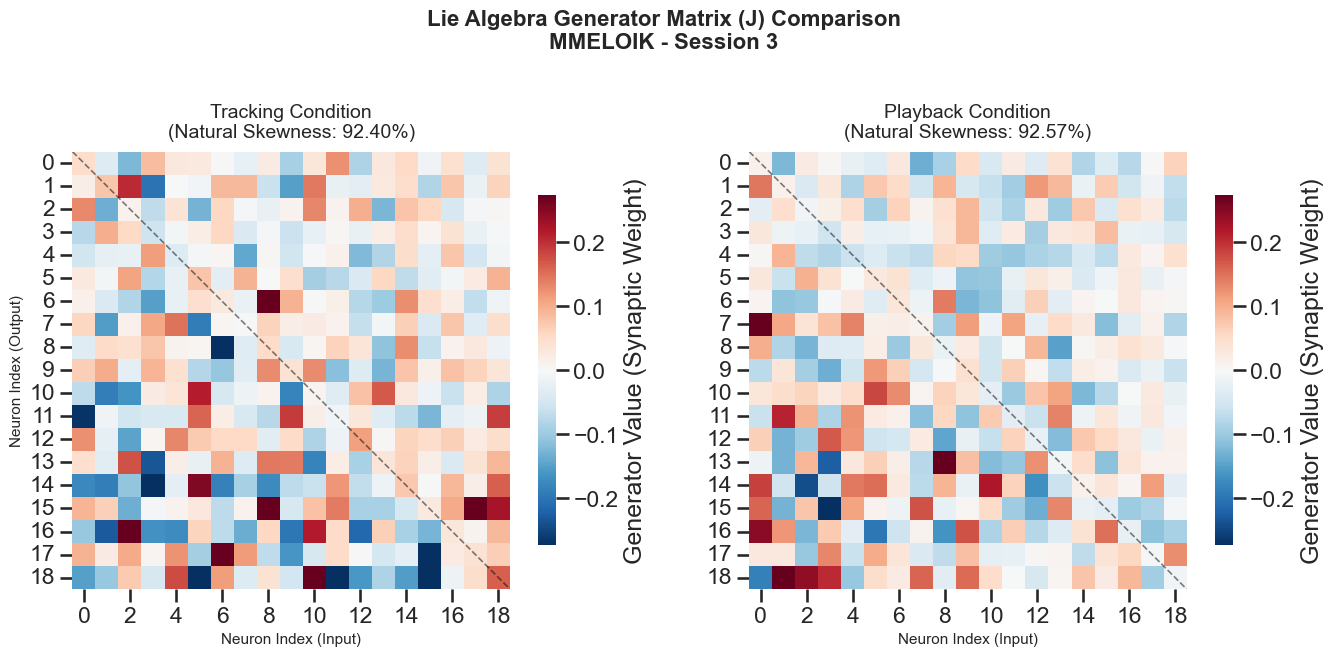

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score

# ==========================================
# 0. 重新定义完整版拟合函数 (确保返回 4 个值)
# ==========================================
def fit_lie_algebra_with_leak_full(r, x_dot, dt=0.005):
    T, N = r.shape
    dr_dt = np.gradient(r, dt, axis=0) 
    
    U_rot = r * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, r]) 
    
    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt, rcond=None)
    weights = weights_T.T
    
    J_unconstrained = weights[:, :N]
    L_leak = weights[:, N:]
    
    J_skew = 0.5 * (J_unconstrained - J_unconstrained.T)
    norm_total = np.linalg.norm(J_unconstrained)
    norm_skew = np.linalg.norm(J_skew)
    skewness_ratio = norm_skew / (norm_total + 1e-9)
    
    dr_dt_pred = U_rot @ J_skew.T + r @ L_leak.T
    r2 = r2_score(dr_dt.flatten(), dr_dt_pred.flatten())
    
    # 强制返回 4 个值: 原始J, 反对称J, 偏斜度, R2
    return J_unconstrained, J_skew, skewness_ratio, r2

# ==========================================
# 1. 封装：生成元 J 矩阵热图对比函数
# ==========================================
def plot_generator_heatmap(subject, session_idx, n_dict, f_dict):
    print("\n" + "=" * 60)
    print(f"🔥 Visualizing J Matrix: Subject [{subject}] | Session [{session_idx}]")
    print("=" * 60)
    
    try:
        r_full = n_dict[subject][session_idx].T
        f_df = f_dict[subject][session_idx]
        x_dot_full = f_df['Speed_x'].values
        conditions = f_df['Condition'].values
    except IndexError:
        print(f"⚠️ 找不到数据！个体 {subject} 没有 Session {session_idx}。")
        return

    J_results = {}

    # 拟合提取矩阵
    for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
        mask = (conditions == val)
        if np.sum(mask) > 500:
            r_sub = r_full[mask]
            x_dot_sub = x_dot_full[mask]
            
            # 使用上面刚刚定义的完整版函数
            J_unconstrained, J_skew, skewness, r2 = fit_lie_algebra_with_leak_full(r_sub, x_dot_sub)
            J_results[label] = {
                'J_raw': J_unconstrained,
                'skewness': skewness
            }

    if not J_results:
        print("⚠️ 数据量过少，无法画图。")
        return

    # 找到全局最大绝对值，统一色带范围 (vmin, vmax)
    all_J = np.concatenate([d['J_raw'].flatten() for d in J_results.values()])
    max_val = np.percentile(np.abs(all_J), 98) # 取 98% 分位数过滤极值

    # 画图
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for i, label in enumerate(['Tracking', 'Playback']):
        ax = axes[i]
        if label not in J_results:
            ax.set_visible(False)
            continue
            
        J_raw = J_results[label]['J_raw']
        skewness = J_results[label]['skewness']
        
        # 使用 seaborn 热图
        sns.heatmap(J_raw, center=0, cmap='RdBu_r', 
                    vmin=-max_val, vmax=max_val, 
                    annot=False, square=True,    
                    cbar_kws={'label': 'Generator Value (Synaptic Weight)', 'shrink': 0.8},
                    ax=ax)
        ax.plot([0, J_raw.shape[1]], [0, J_raw.shape[0]], linestyle='--', color='black', linewidth=1.2, alpha=0.5)
        
        ax.set_title(f"{label} Condition\n(Natural Skewness: {skewness:.2%})", fontsize=14, pad=10)
        ax.set_xlabel("Neuron Index (Input)", fontsize=11)
        if i == 0:
            ax.set_ylabel("Neuron Index (Output)", fontsize=11)

    plt.suptitle(f"Lie Algebra Generator Matrix (J) Comparison\n{subject} - Session {session_idx}", 
                 fontsize=16, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==========================================
# 调用示例：查看某个体的特定 Session
# ==========================================
plot_generator_heatmap(
    subject='MMELOIK', 
    session_idx=3, 
    n_dict=n_data_grouped, 
    f_dict=f_data_grouped
)

## <a id='toc2_3_'></a>[Dynamical Systems Stability Analysis](#toc0_)


🔍 Analyzing Spectrum: Subject [HERCULE] | Session [0]


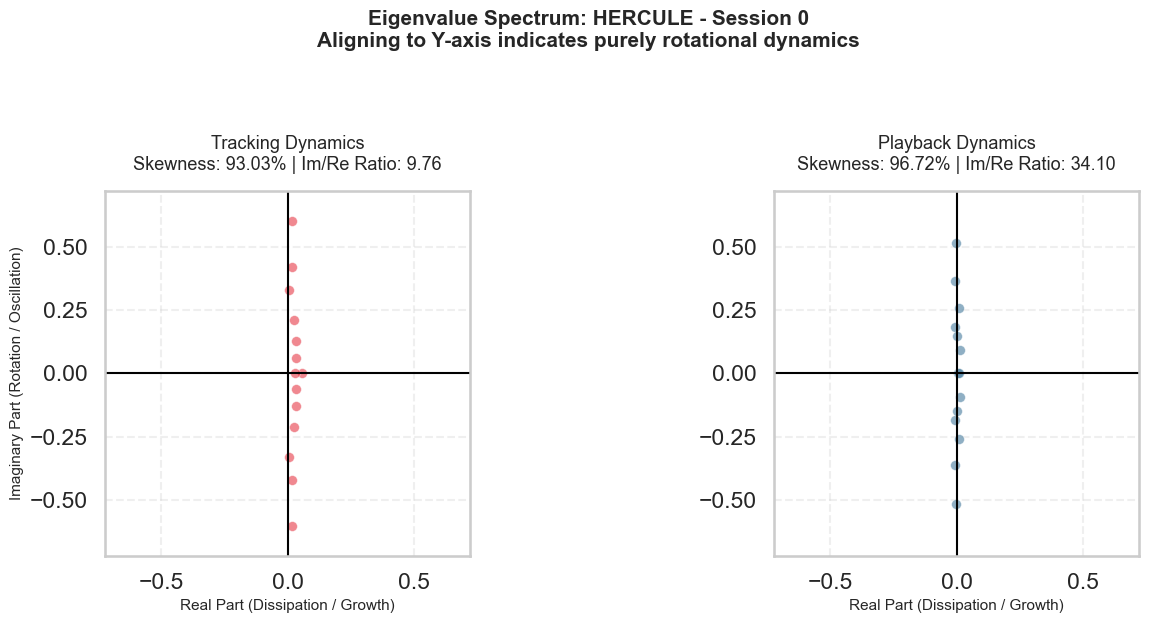

  [Tracking] 实部均值(耗散): 0.0256 | 虚部均值(旋转): 0.2502 | 虚实比: 9.76
  [Playback] 实部均值(耗散): 0.0065 | 虚部均值(旋转): 0.2227 | 虚实比: 34.10

🔍 Analyzing Spectrum: Subject [MMELOIK] | Session [0]


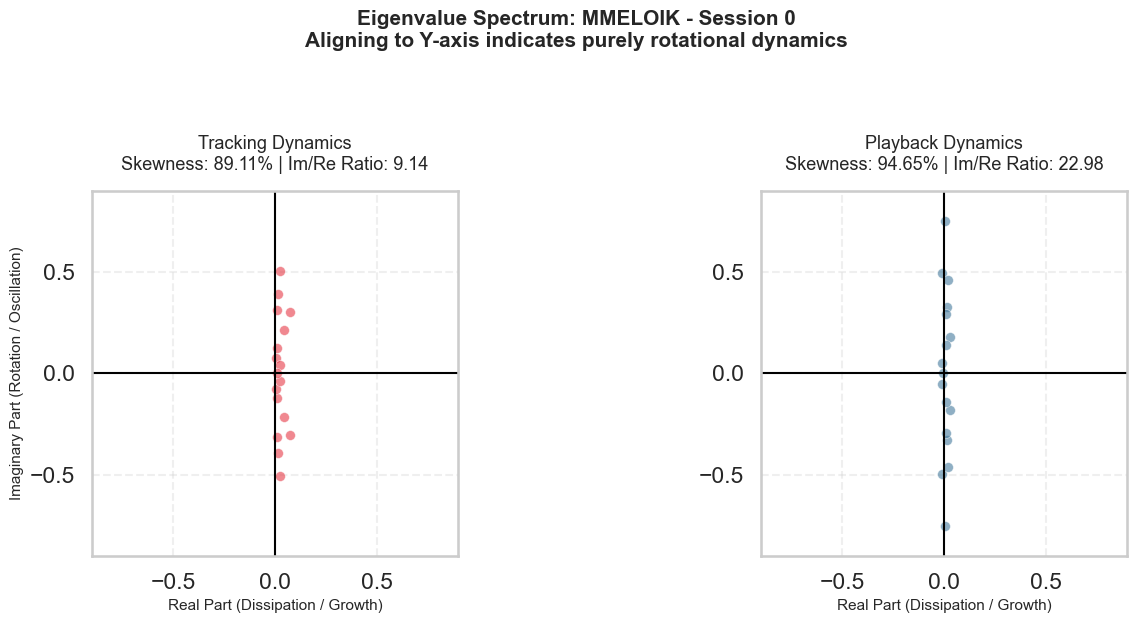

  [Tracking] 实部均值(耗散): 0.0252 | 虚部均值(旋转): 0.2300 | 虚实比: 9.14
  [Playback] 实部均值(耗散): 0.0138 | 虚部均值(旋转): 0.3163 | 虚实比: 22.98

🔍 Analyzing Spectrum: Subject [NAPOLEON] | Session [0]


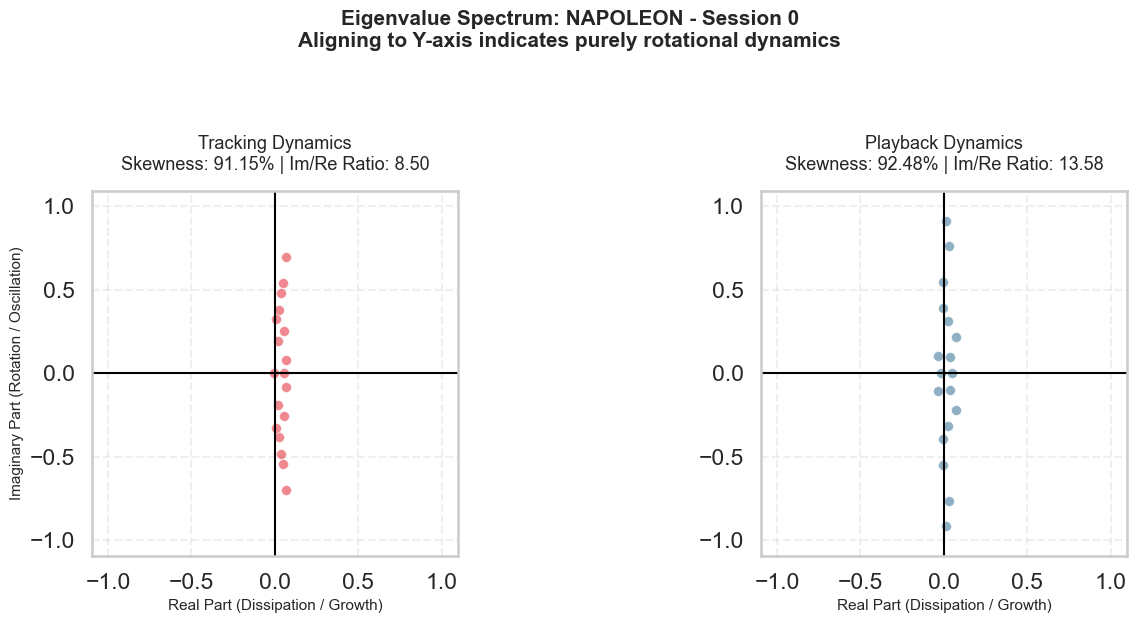

  [Tracking] 实部均值(耗散): 0.0386 | 虚部均值(旋转): 0.3282 | 虚实比: 8.50
  [Playback] 实部均值(耗散): 0.0274 | 虚部均值(旋转): 0.3726 | 虚实比: 13.58


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# ==========================================
# 1. 拟合函数 (确保返回完整的 J 矩阵)
# ==========================================
def fit_lie_algebra_with_leak(r, x_dot, dt=0.005):
    T, N = r.shape
    dr_dt = np.gradient(r, dt, axis=0) 
    
    U_rot = r * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, r]) 
    
    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt, rcond=None)
    weights = weights_T.T
    
    J_unconstrained = weights[:, :N]
    L_leak = weights[:, N:]
    
    J_skew = 0.5 * (J_unconstrained - J_unconstrained.T)
    norm_total = np.linalg.norm(J_unconstrained)
    norm_skew = np.linalg.norm(J_skew)
    skewness_ratio = norm_skew / (norm_total + 1e-9)
    
    dr_dt_pred = U_rot @ J_skew.T + r @ L_leak.T
    r2 = r2_score(dr_dt.flatten(), dr_dt_pred.flatten())
    
    return J_unconstrained, J_skew, skewness_ratio, r2

# ==========================================
# 2. 封装分析与画图函数
# ==========================================
def plot_eigenvalue_spectrum(subject, session_idx, n_dict, f_dict):
    print("\n" + "=" * 60)
    print(f"🔍 Analyzing Spectrum: Subject [{subject}] | Session [{session_idx}]")
    print("=" * 60)
    
    # 获取特定个体和 Session 的数据
    try:
        r_full = n_dict[subject][session_idx].T
        f_df = f_dict[subject][session_idx]
        x_dot_full = f_df['Speed_x'].values
        conditions = f_df['Condition'].values
    except IndexError:
        print(f"⚠️ 找不到对应的 Session 数据！个体 {subject} 只有 {len(n_dict[subject])} 个 Session。")
        return

    J_dict = {}

    # 循环提取并拟合
    for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
        mask = (conditions == val)
        if np.sum(mask) > 500:
            r_sub = r_full[mask]
            x_dot_sub = x_dot_full[mask]
            
            J, J_skew, skewness, r2 = fit_lie_algebra_with_leak(r_sub, x_dot_sub)
            J_dict[label] = {
                'J': J,
                'skewness': skewness
            }

    if not J_dict:
        print("⚠️ 数据量过少，无法进行特征值分析。")
        return

    # ==========================================
    # 3. 绘制左右对比特征值复平面
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = {'Tracking': '#E63946', 'Playback': '#457B9D'} # 使用更好看的红蓝配色

    # 找出全局最大特征值，用于统一坐标轴比例
    all_eigenvalues = np.concatenate([np.linalg.eigvals(d['J']) for d in J_dict.values()])
    max_val = np.max(np.abs(all_eigenvalues)) * 1.2

    for i, label in enumerate(['Tracking', 'Playback']):
        ax = axes[i]
        
        if label not in J_dict:
            ax.set_visible(False)
            continue
            
        J_matrix = J_dict[label]['J']
        skewness = J_dict[label]['skewness']
        
        # 计算特征值
        eigenvalues = np.linalg.eigvals(J_matrix)
        real_parts = np.real(eigenvalues)
        imag_parts = np.imag(eigenvalues)
        
        # 计算虚实比 (Imaginary / Real Ratio)
        mean_real = np.mean(np.abs(real_parts))
        mean_imag = np.mean(np.abs(imag_parts))
        vi_ratio = mean_imag / (mean_real + 1e-9)
        
        # 散点图绘制
        ax.scatter(real_parts, imag_parts, color=colors[label], s=50, alpha=0.6, edgecolors='white', linewidth=0.5)
        
        # 画十字坐标轴 (0,0)
        ax.axhline(0, color='black', linewidth=1.5, zorder=1)
        ax.axvline(0, color='black', linewidth=1.5, zorder=1)
        ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
        
        # 设置统一的轴范围
        ax.set_xlim(-max_val, max_val)
        ax.set_ylim(-max_val, max_val)
        
        # 🌟 强制长宽比为 1:1，防止复平面被拉伸变形
        ax.set_aspect('equal', 'box')
        
        # 标签和标题
        ax.set_title(f"{label} Dynamics\nSkewness: {skewness:.2%} | Im/Re Ratio: {vi_ratio:.2f}", fontsize=13, pad=15)
        ax.set_xlabel("Real Part (Dissipation / Growth)", fontsize=11)
        if i == 0:
            ax.set_ylabel("Imaginary Part (Rotation / Oscillation)", fontsize=11)

    plt.suptitle(f"Eigenvalue Spectrum: {subject} - Session {session_idx}\nAligning to Y-axis indicates purely rotational dynamics", fontsize=15, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 4. 打印统计报告
    # ==========================================
    for label in ['Tracking', 'Playback']:
        if label in J_dict:
            eig = np.linalg.eigvals(J_dict[label]['J'])
            real_mean = np.mean(np.abs(np.real(eig)))
            imag_mean = np.mean(np.abs(np.imag(eig)))
            ratio = imag_mean / (real_mean + 1e-9)
            print(f"  [{label}] 实部均值(耗散): {real_mean:.4f} | 虚部均值(旋转): {imag_mean:.4f} | 虚实比: {ratio:.2f}")

# ==========================================
# 调用示例：一键查看所有个体的 第 0 个 Session
# ==========================================
# 你可以修改 session_idx 或 subject 来查看特定的图表
for subject_name in n_data_grouped.keys():
    plot_eigenvalue_spectrum(
        subject=subject_name, 
        session_idx=0, 
        n_dict=n_data_grouped, 
        f_dict=f_data_grouped
    )

🚀 开始跨 Session 提取动力学物理特征 (Eigenvalue Metrics)...


✅ 成功配对 17 个 Session！


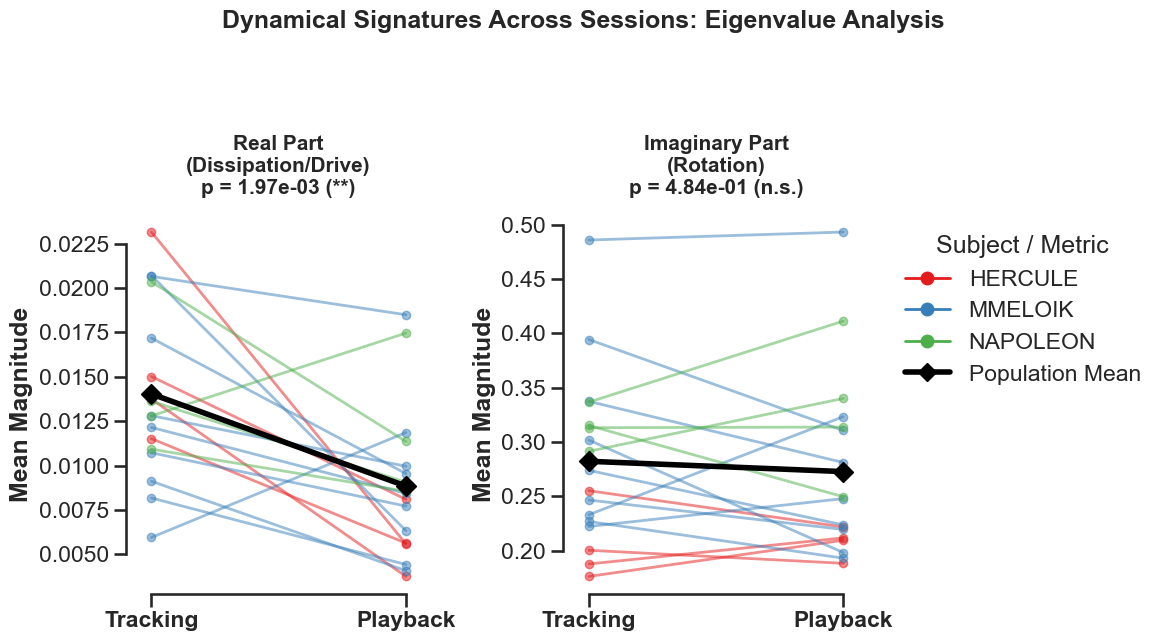

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# ==========================================
# 1. 批量提取 17 个 Session 的特征值指标
# ==========================================
all_eig_results = []
min_points = 500

print(f"🚀 开始跨 Session 提取动力学物理特征 (Eigenvalue Metrics)...")

for subject in n_data_grouped.keys():
    sub_n = n_data_grouped[subject]
    sub_f = f_data_grouped[subject]
    
    for idx, (n_raw, f_df) in enumerate(zip(sub_n, sub_f)):
        r_full = n_raw.T.astype(np.float32)
        x_dot_full = f_df['Speed_x'].values
        conditions = f_df['Condition'].values
        
        # 预处理：L2 归一化
        r_n = r_full / (np.linalg.norm(r_full, axis=1, keepdims=True) + 1e-9)
        
        session_metrics = {'Subject': subject, 'Session': idx}
        valid_pair = True
        
        for val, cond_name in [(0.0, 'Tracking'), (1.0, 'Playback')]:
            mask = (conditions == val)
            if np.sum(mask) < min_points:
                valid_pair = False; break
                
            r_sub = r_n[mask]
            x_dot_sub = x_dot_full[mask]
            
            try:
                # 使用你目前的拟合函数提取 J 矩阵 (建议包含 Leak 项以获得完整特征值)
                J_raw, _, _, _ = fit_lie_algebra_with_leak(r_sub, x_dot_sub)
                
                # 计算特征值
                eigvals = np.linalg.eigvals(J_raw)
                
                # 指标 1: 实部均值 (代表系统的能量耗散/驱动强度)
                # 指标 2: 虚部均值 (代表系统的旋转基频)
                session_metrics[f'{cond_name}_real'] = np.mean(np.abs(np.real(eigvals)))
                session_metrics[f'{cond_name}_imag'] = np.mean(np.abs(np.imag(eigvals)))
                
            except:
                valid_pair = False; break
        
        if valid_pair:
            all_eig_results.append(session_metrics)

df_eig = pd.DataFrame(all_eig_results)
print(f"✅ 成功配对 {len(df_eig)} 个 Session！")

# ==========================================
# 2. 统计检验
# ==========================================
t_real, p_real = ttest_rel(df_eig['Tracking_real'], df_eig['Playback_real'])
t_imag, p_imag = ttest_rel(df_eig['Tracking_imag'], df_eig['Playback_imag'])

import matplotlib.lines as mlines

# ==========================================
# 3. 论文级配对连线图 (修复版：按个体上色 + 修复 X 轴)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set_theme(style="ticks", context="talk")

# 为不同的 Subject 分配固定的颜色 (例如 HERCULE, MMELOIK, NAPOLEON)
subjects = df_eig['Subject'].unique()
palette = sns.color_palette("Set1", n_colors=len(subjects)) # 使用 Set1 高对比配色
subject_colors = dict(zip(subjects, palette))

# 定义两个子图的配置
metrics_config = [
    ('real', 'Real Part\n(Dissipation/Drive)', p_real), 
    ('imag', 'Imaginary Part\n(Rotation)', p_imag)
]

for i, (m_type, title, p_val) in enumerate(metrics_config):
    ax = axes[i]
    col_tr, col_pb = f'Tracking_{m_type}', f'Playback_{m_type}'
    
    # 遍历每一个 Session 画连线
    for idx, row in df_eig.iterrows():
        y_tr = row[col_tr]
        y_pb = row[col_pb]
        subj = row['Subject']
        color = subject_colors[subj]
        
        # 💡 强制使用数字 0 和 1 作为 x 坐标，彻底避免字符串重叠 bug
        ax.plot([0, 1], [y_tr, y_pb], 
                color=color, alpha=0.5, lw=2, marker='o', markersize=6)

    # 叠加群体均值线 (粗黑线)
    mean_tr = df_eig[col_tr].mean()
    mean_pb = df_eig[col_pb].mean()
    ax.plot([0, 1], [mean_tr, mean_pb], 
            color='black', marker='D', markersize=10, lw=4, zorder=10)
    
    # 💡 统一设置 X 轴标签
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Tracking', 'Playback'], fontweight='bold')
    ax.set_xlim(-0.1, 1.1) # 给左右留一点空隙，避免点卡在边缘
    
    # 设置显著性与标题
    sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    ax.set_title(f"{title}\np = {p_val:.2e} ({sig_text})", fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel("Mean Magnitude", fontweight='bold')
    
    # 去除顶部和右侧边框，使图表更清爽
    sns.despine(ax=ax, trim=True)

# ==========================================
# 4. 制作全局自定义图例 (Legend)
# ==========================================
# 为不同的 Subject 创建图例项
legend_handles = [mlines.Line2D([], [], color=color, marker='o', lw=2, label=subj) 
                  for subj, color in subject_colors.items()]
# 加上黑色的均值图例项
legend_handles.append(mlines.Line2D([], [], color='black', marker='D', lw=4, label='Population Mean'))

# 将图例放在右侧子图的外面
axes[1].legend(handles=legend_handles, title='Subject / Metric', 
               bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.suptitle("Dynamical Signatures Across Sessions: Eigenvalue Analysis", fontsize=18, y=1.08, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import wilcoxon, ttest_rel

# ==========================================
# 1. 整理统计表格 (包含配对差异)
# ==========================================
# 创建一个专门用于统计展示的副本
df_stats = df_eig.copy()

# 计算配对差异 (Tracking - Playback)
df_stats['Real_Diff'] = df_stats['Tracking_real'] - df_stats['Playback_real']
df_stats['Imag_Diff'] = df_stats['Tracking_imag'] - df_stats['Playback_imag']

print("\n" + "="*70)
print("📈 特征值动力学全细节记录 (Mean Magnitude)")
print("="*70)
# 打印所有 Session 的具体数值
print(df_stats[['Subject', 'Session', 'Tracking_real', 'Playback_real', 'Real_Diff', 
                'Tracking_imag', 'Playback_imag', 'Imag_Diff']].round(5).to_string(index=False))

# ==========================================
# 2. 执行显著性检验 (建议使用 Wilcoxon 符号秩检验，比 T-test 更稳健)
# ==========================================
print("\n" + "-"*70)
print("⚖️ 统计显著性分析报告 (N = {} Sessions)".format(len(df_stats)))
print("-"*70)

metrics = [
    ('real', '实部 (System Drive/Dissipation)'),
    ('imag', '虚部 (Rotational Core)')
]

for key, name in metrics:
    tr_vals = df_stats[f'Tracking_{key}']
    pb_vals = df_stats[f'Playback_{key}']
    
    # 执行配对检验
    stat, p_val = wilcoxon(tr_vals, pb_vals)
    
    # 计算均值和提升比例
    m_tr, m_pb = tr_vals.mean(), pb_vals.mean()
    change = (m_tr - m_pb) / m_pb * 100
    
    print(f"🔹 {name}:")
    print(f"   ↳ Tracking 均值: {m_tr:.5f} | Playback 均值: {m_pb:.5f}")
    print(f"   ↳ P值 (Wilcoxon): {p_val:.4e}")
    print(f"   ↳ 相对变化: {change:+.2f}%")
    
    if p_val < 0.05:
        verdict = "✅ 显著差异"
    else:
        verdict = "⚠️ 无显著差异"
    print(f"   ↳ 结论: {verdict}")
    print("")

print("="*70)


📈 特征值动力学全细节记录 (Mean Magnitude)
 Subject  Session  Tracking_real  Playback_real  Real_Diff  Tracking_imag  Playback_imag  Imag_Diff
 HERCULE        0        0.02316        0.00559    0.01756        0.25519        0.22176    0.03343
 HERCULE        1        0.01152        0.00564    0.00588        0.17619        0.20949   -0.03330
 HERCULE        2        0.01375        0.00376    0.00998        0.18765        0.21169   -0.02404
 HERCULE        4        0.01502        0.00810    0.00692        0.20030        0.18825    0.01205
 MMELOIK        0        0.01719        0.00956    0.00763        0.23301        0.32333   -0.09032
 MMELOIK        1        0.01282        0.00997    0.00285        0.22679        0.19304    0.03375
 MMELOIK        2        0.02066        0.01850    0.00216        0.48610        0.49343   -0.00734
 MMELOIK        3        0.01073        0.00772    0.00300        0.33745        0.28113    0.05633
 MMELOIK        4        0.00818        0.00443    0.00375        0.

## <a id='toc2_4_'></a>[Latent Phase-Coupling Analysis](#toc0_)

In [ ]:
import gc
import torch
import numpy as np
import pandas as pd
import cebra
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr, wilcoxon
from sklearn.feature_selection import mutual_info_regression
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 生物学延迟对齐函数
# ==========================================
def get_best_mi_jitter(n_vel, p_vel, cond, target_val, window_samples=50):
    """
    在微小窗口内寻找最高互信息，校准神经信号与行为信号的延迟。
    """
    mask_full = (cond == target_val)
    if np.sum(mask_full) < 800:
        return 0.0, 0.0
        
    n_seg = n_vel[mask_full]
    p_seg = p_vel[mask_full]
    
    best_mi = -1.0
    best_r = 0.0
    
    # 尝试不同的延迟 (Shifts)
    for shift in range(-window_samples, window_samples + 1):
        if shift > 0:
            n_tmp, p_tmp = n_seg[shift:], p_seg[:-shift]
        elif shift < 0:
            n_tmp, p_tmp = n_seg[:shift], p_seg[abs(shift):]
        else:
            n_tmp, p_tmp = n_seg, p_seg
            
        # 仅在运动显著的时段计算
        v_thresh = np.std(p_tmp) * 0.1
        m = (np.abs(p_tmp) > v_thresh)
        
        if np.sum(m) > 500:
            # 随机采样以加速 MI 计算
            sample_size = min(1500, np.sum(m))
            idx = np.random.choice(np.where(m)[0], sample_size, replace=False)
            curr_mi = mutual_info_regression(p_tmp[idx].reshape(-1, 1), n_tmp[idx])[0]
            if curr_mi > best_mi:
                best_mi = curr_mi
                best_r = np.abs(pearsonr(n_tmp[m], p_tmp[m])[0])
                
    return max(0.0, best_mi), best_r

# ==========================================
# 2. 自动化批处理：潜空间相位耦合
# ==========================================
coupling_results = []

for subject in n_data_grouped.keys():
    print(f"\n" + "🌀" * 30)
    print(f"Refined Phase Analysis: {subject}")
    print("🌀" * 30)
    
    sub_n = n_data_grouped[subject]
    sub_f = f_data_grouped[subject]
    
    for idx, (n_raw, f_df) in enumerate(zip(sub_n, sub_f)):
        torch.cuda.empty_cache()
        gc.collect()
        
        try:
            # A. 数据预处理 (L2 归一化)
            r_v = n_raw.T.astype(np.float32)
            pos_v = f_df['Position'].values.astype(np.float32)
            cond_v = f_df['Condition'].values
            
            norms = np.linalg.norm(r_v, axis=1, keepdims=True)
            r_n = r_v / (norms + 1e-9)
            
            # B. CEBRA 降维提取流形
            model = cebra.CEBRA(model_architecture='offset10-model', batch_size=512, 
                                output_dimension=3, max_iterations=1500, 
                                distance='cosine', conditional='time_delta', device='cuda')
            model.fit(r_n, pos_v)
            z = model.transform(r_n)
            
            # C. 提取相位动力学 (Phase Dynamics)
            z_s = gaussian_filter1d(z, sigma=15, axis=0) # 平滑
            z_2d = PCA(n_components=2).fit_transform(z_s) # 投影到主要旋转平面
            z_c = z_2d - np.mean(z_2d, axis=0)
            
            # 计算神经旋转速度 (Angular Velocity)
            theta = np.unwrap(np.arctan2(z_c[:, 1], z_c[:, 0]))
            n_vel = np.gradient(theta, 0.005)
            
            # 计算物理位置速度
            p_vel = np.gradient(np.unwrap(np.deg2rad(pos_v * (360/28))), 0.005) # 将cm映射回角度
            
            # D. 计算两个 Condition 下的耦合强度
            for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
                mi, r_val = get_best_mi_jitter(n_vel, p_vel, cond_v, val)
                
                if mi > 0.0:
                    coupling_results.append({
                        'Subject': subject,
                        'Session': idx,
                        'Condition': label,
                        'MI': mi,
                        'Pearson_R': r_val
                    })
            
            print(f"  ✅ Session {idx} Coupling Analysis Done.")
            
        except Exception as e:
            print(f"  ⚠️ Session {idx} Skipped: {e}")

# ==========================================
# 3. 跨个体统计检验
# ==========================================
df_coupling = pd.DataFrame(coupling_results)

print("\n" + "="*50)
print("📊 最终统计报告：神经-行为相位耦合 (MI)")
print("="*50)

# 计算 Tracking 和 Playback 的配对对比
pivot_mi = df_coupling.pivot_table(index=['Subject', 'Session'], columns='Condition', values='MI').dropna()

if not pivot_mi.empty:
    stat, p_val = wilcoxon(pivot_mi['Tracking'], pivot_mi['Playback'])
    print(pivot_mi.mean())
    print(f"\n⚖️ Wilcoxon 配对检验 (Tracking vs Playback):")
    print(f"   P-value = {p_val:.4e}")
    if p_val < 0.05:
        print("   结论: Tracking 条件下的耦合显著强于 Playback。")
    else:
        print("   结论: 两种条件下耦合强度无显著差异。")
else:
    print("有效配对数据不足。")


🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀
Refined Phase Analysis: HERCULE
🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀
  ✅ Session 0 Coupling Analysis Done.
  ✅ Session 1 Coupling Analysis Done.
  ✅ Session 2 Coupling Analysis Done.
  ✅ Session 3 Coupling Analysis Done.
  ✅ Session 4 Coupling Analysis Done.

🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀
Refined Phase Analysis: MMELOIK
🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀
  ✅ Session 0 Coupling Analysis Done.
  ✅ Session 1 Coupling Analysis Done.
  ✅ Session 2 Coupling Analysis Done.
  ✅ Session 3 Coupling Analysis Done.
  ✅ Session 4 Coupling Analysis Done.
  ✅ Session 5 Coupling Analysis Done.
  ✅ Session 6 Coupling Analysis Done.
  ✅ Session 7 Coupling Analysis Done.
  ✅ Session 8 Coupling Analysis Done.

🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀
Refined Phase Analysis: NAPOLEON
🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀
  ✅ Session 0 Coupling Analysis Done.
  ✅ Session 1 Coupling Analysis Done.
  ✅ Session 2 Coupling Analysis Done.
  ✅ Session 3 Coupling Analysis Done.

📊 最终统计报告：神经-行为相位耦合 (MI)
Condi

## <a id='toc2_5_'></a>[Latent Physical Phase-Coupling Analysis](#toc0_)

In [ ]:
import gc
import torch
import numpy as np
import pandas as pd
import cebra
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr, wilcoxon
from sklearn.feature_selection import mutual_info_regression
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 生物学延迟对齐函数 (Jittering)
# ==========================================
def get_best_mi_jitter(n_vel, p_vel, cond, target_val, window_samples=50):
    """
    在微小窗口内寻找最高互信息，校准神经信号与行为信号的生理延迟。
    """
    mask_full = (cond == target_val)
    if np.sum(mask_full) < 800:
        return 0.0, 0.0
        
    n_seg = n_vel[mask_full]
    p_seg = p_vel[mask_full]
    
    best_mi = -1.0
    best_r = 0.0
    
    # 尝试不同的延迟 (Shifts)
    for shift in range(-window_samples, window_samples + 1):
        if shift > 0:
            n_tmp, p_tmp = n_seg[shift:], p_seg[:-shift]
        elif shift < 0:
            n_tmp, p_tmp = n_seg[:shift], p_seg[abs(shift):]
        else:
            n_tmp, p_tmp = n_seg, p_seg
            
        # 仅在物理运动显著的时段计算 (过滤静止噪音)
        v_thresh = np.std(p_tmp) * 0.1
        m = (np.abs(p_tmp) > v_thresh)
        
        if np.sum(m) > 500:
            sample_size = min(1500, np.sum(m))
            idx = np.random.choice(np.where(m)[0], sample_size, replace=False)
            curr_mi = mutual_info_regression(p_tmp[idx].reshape(-1, 1), n_tmp[idx])[0]
            if curr_mi > best_mi:
                best_mi = curr_mi
                best_r = np.abs(pearsonr(n_tmp[m], p_tmp[m])[0])
                
    return max(0.0, best_mi), best_r

# ==========================================
# 2. 潜空间物理相位耦合主循环
# ==========================================
print("🚀 启动: 潜空间物理相位耦合分析 (Latent Physical Phase-Coupling Analysis)")
coupling_results = []

for subject in n_data_grouped.keys():
    print(f"\n🌀 正在处理个体: {subject}")
    
    sub_n = n_data_grouped[subject]
    sub_f = f_data_grouped[subject]
    
    for idx, (n_raw, f_df) in enumerate(zip(sub_n, sub_f)):
        torch.cuda.empty_cache()
        gc.collect()
        
        try:
            # --- A. 数据提取与金钟罩容错 (NaN 过滤) ---
            r_raw_T = n_raw.T
            pos_raw = f_df['Position'].values
            cond_raw = f_df['Condition'].values
            
            v_mask = ~np.isnan(pos_raw)
            pos_v = pos_raw[v_mask].astype(np.float32)
            cond_v = cond_raw[v_mask]
            r_v = r_raw_T[v_mask].astype(np.float32)
            
            # --- B. 剥离幅度噪音 (L2 Normalization) ---
            norms = np.linalg.norm(r_v, axis=1, keepdims=True)
            r_n = r_v / (norms + 1e-9)
            
            # --- C. CEBRA 提取拓扑流形 ---
            model = cebra.CEBRA(model_architecture='offset10-model', batch_size=512, 
                                output_dimension=3, max_iterations=1500, 
                                distance='cosine', conditional='time_delta', device='cuda')
            model.fit(r_n, pos_v)
            z = model.transform(r_n)
            
            # --- D. PCA 投影提取神经相位动力学 ---
            z_s = gaussian_filter1d(z, sigma=15, axis=0) 
            z_2d = PCA(n_components=2).fit_transform(z_s) 
            z_c = z_2d - np.mean(z_2d, axis=0)
            
            theta = np.unwrap(np.arctan2(z_c[:, 1], z_c[:, 0]))
            n_vel = np.gradient(theta, 0.005)
            
            # --- E. 物理相位动力学完美映射 (关键步骤) ---
            # 28cm 轨道 -> 360度完整相位的转换
            p_vel = np.gradient(np.unwrap(np.deg2rad(pos_v * (360.0/28.0))), 0.005) 
            
            # --- F. 条件测算与校准 ---
            for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
                mi, r_val = get_best_mi_jitter(n_vel, p_vel, cond_v, val)
                
                if mi > 0.0:
                    coupling_results.append({
                        'Subject': subject,
                        'Session': idx,
                        'Condition': label,
                        'MI': mi,
                        'Pearson_R': r_val
                    })
            
            print(f"  ✅ Session {idx} 耦合分析完成.")
            
        except Exception as e:
            print(f"  ⚠️ Session {idx} 跳过: {e}")

# ==========================================
# 3. 科研级跨个体统计检验
# ==========================================
df_coupling = pd.DataFrame(coupling_results)

print("\n" + "="*60)
print("📊 潜空间物理相位耦合摘要 (已校准延迟 & 物理维度映射)")
print("="*60)

# 使用透视表保证成对出现 (Paired data)
pivot_mi = df_coupling.pivot_table(index=['Subject', 'Session'], columns='Condition', values='MI').dropna()

if not pivot_mi.empty:
    stat, p_val = wilcoxon(pivot_mi['Tracking'], pivot_mi['Playback'])
    
    # 构建包含均值、标准差、标准误的完整表格
    stats_df = pivot_mi.describe()
    stats_df.loc['sem'] = pivot_mi.sem()
    
    print(stats_df.loc[['mean', 'std', 'sem']])
    print(f"\n⚖️ 配对 Wilcoxon 检验 P-value: {p_val:.4e}")
    
    mean_diff_pct = ((pivot_mi['Tracking'].mean() / pivot_mi['Playback'].mean()) - 1) * 100
    if p_val < 0.05:
        print(f"📈 结论: Tracking 耦合显著强于 Playback (差异 {mean_diff_pct:.2f}%).")
    else:
        print(f"🤝 结论: 两种条件下耦合强度无显著差异 (表现出高度的感觉表征不变性).")
else:
    print("未能获得足够的配对有效数据。")
print("="*60)

🚀 启动: 潜空间物理相位耦合分析 (Latent Physical Phase-Coupling Analysis)

🌀 正在处理个体: HERCULE
  ✅ Session 0 耦合分析完成.
  ✅ Session 1 耦合分析完成.
  ✅ Session 2 耦合分析完成.
  ✅ Session 3 耦合分析完成.
  ✅ Session 4 耦合分析完成.

🌀 正在处理个体: MMELOIK
  ✅ Session 0 耦合分析完成.
  ✅ Session 1 耦合分析完成.
  ✅ Session 2 耦合分析完成.
  ✅ Session 3 耦合分析完成.
  ✅ Session 4 耦合分析完成.
  ✅ Session 5 耦合分析完成.
  ✅ Session 6 耦合分析完成.
  ✅ Session 7 耦合分析完成.
  ✅ Session 8 耦合分析完成.

🌀 正在处理个体: NAPOLEON
  ✅ Session 0 耦合分析完成.
  ✅ Session 1 耦合分析完成.
  ✅ Session 2 耦合分析完成.
  ✅ Session 3 耦合分析完成.

📊 潜空间物理相位耦合摘要 (已校准延迟 & 物理维度映射)
Condition  Playback  Tracking
mean       0.063539  0.074489
std        0.008892  0.017052
sem        0.002157  0.004136

⚖️ 配对 Wilcoxon 检验 P-value: 1.2863e-02
📈 结论: Tracking 耦合显著强于 Playback (差异 17.23%).


In [ ]:
import pandas as pd
from scipy.stats import wilcoxon

# 假设上一步得到的结果 DataFrame 名为 df_coupling
# 列名包含: 'Subject', 'Session', 'Condition', 'MI', 'Pearson_R'

# ==========================================
# 1. 数据汇总统计 (按 Condition 分组)
# ==========================================
print("📊 --- 神经相位耦合 (MI) 全局统计摘要 ---")
summary = df_coupling.groupby('Condition').agg({
    'MI': ['mean', 'std', 'sem'],
    'Pearson_R': ['mean', 'std']
}).round(4)
print(summary)
print("-" * 55)

# ==========================================
# 2. 配对统计检验 (Paired Test)
# ==========================================
# 【关键修改】使用 pivot_table 并把 Subject 和 Session 联合作为索引
pivot_df = df_coupling.pivot_table(
    index=['Subject', 'Session'], 
    columns='Condition', 
    values='MI'
).dropna()

if len(pivot_df) > 1:
    # Wilcoxon 符号秩检验
    stat, p_val = wilcoxon(pivot_df['Tracking'], pivot_df['Playback'])
    
    # 计算均值差异
    mi_diff = pivot_df['Tracking'].mean() - pivot_df['Playback'].mean()
    increase_pct = (mi_diff / pivot_df['Playback'].mean()) * 100

    print(f"⚖️ 统计显著性报告 (有效配对 N = {len(pivot_df)}):")
    print(f"   ↳ 互信息 (MI) 差异 P-value: {p_val:.4e}")
    
    if mi_diff > 0:
        print(f"   ↳ Tracking 相比 Playback MI 提升了: {mi_diff:.4f} (+{increase_pct:.1f}%)")
    else:
        print(f"   ↳ Tracking 相比 Playback MI 降低了: {abs(mi_diff):.4f} ({increase_pct:.1f}%)")
    
    # 结论判断
    if p_val < 0.05 and mi_diff > 0:
        print("   ✅ 结论：显著性达成！主动追踪显著增强了神经流形的相位锁定。")
    elif p_val < 0.05 and mi_diff < 0:
        print("   ✅ 结论：显著性达成！但在被动播放下耦合更强（需进一步解释）。")
    else:
        print("   🤝 结论：差异不显著。大脑展现出了高度的“感觉表征不变性”。")
else:
    print("⚠️ 匹配失败：有效配对 Session 数量不足，无法进行统计检验。")

# ==========================================
# 3. 逐个配对原始数据打印（方便核对）
# ==========================================
print("\n🔍 --- 各个体 & Session 详细配对记录 ---")
# 增加一列展示差异
pivot_df['Diff (TR-PB)'] = pivot_df['Tracking'] - pivot_df['Playback']
print(pivot_df.round(4).sort_index())

📊 --- 神经相位耦合 (MI) 全局统计摘要 ---
               MI                 Pearson_R        
             mean     std     sem      mean     std
Condition                                          
Playback   0.0635  0.0089  0.0022    0.0091  0.0051
Tracking   0.0740  0.0166  0.0039    0.0273  0.0361
-------------------------------------------------------
⚖️ 统计显著性报告 (有效配对 N = 17):
   ↳ 互信息 (MI) 差异 P-value: 1.2863e-02
   ↳ Tracking 相比 Playback MI 提升了: 0.0110 (+17.2%)
   ✅ 结论：显著性达成！主动追踪显著增强了神经流形的相位锁定。

🔍 --- 各个体 & Session 详细配对记录 ---
Condition         Playback  Tracking  Diff (TR-PB)
Subject  Session                                  
HERCULE  0          0.0764    0.0888        0.0124
         1          0.0607    0.1083        0.0476
         2          0.0915    0.0841       -0.0073
         4          0.0622    0.0765        0.0142
MMELOIK  0          0.0600    0.1140        0.0539
         1          0.0586    0.0623        0.0037
         2          0.0627    0.0729        0.0102
         3       

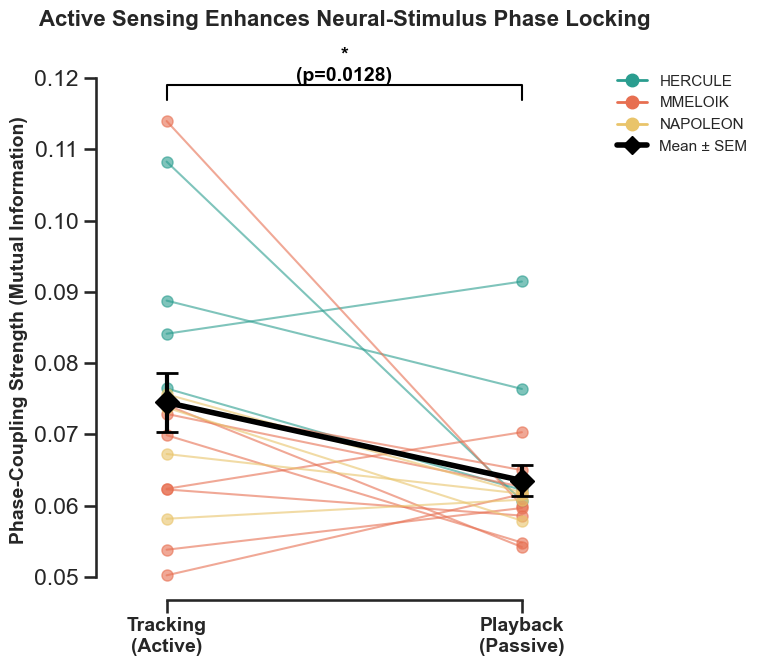

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 定制化绘图：Tracking (左) vs Playback (右)
# ==========================================
# 确保 pivot_df 已经转换为长格式
plot_df = pivot_df.reset_index()

plt.figure(figsize=(8, 7))
sns.set_theme(style="ticks", context="talk")

# 为三只 ferret 分配不同的颜色，增加图表的信息维度
subject_colors = {
    'HERCULE': '#2A9D8F',  # 蓝绿色
    'MMELOIK': '#E76F51',  # 珊瑚红
    'NAPOLEON': '#E9C46A'  # 砂黄色
}

# 1. 画每条细线（注意这里的坐标对应：[0, 1] 对应 [Tracking, Playback]）
for idx, row in plot_df.iterrows():
    subj = row['Subject']
    plt.plot([0, 1], [row['Tracking'], row['Playback']], 
             marker='o', markersize=8, color=subject_colors[subj], 
             alpha=0.6, linewidth=1.5, zorder=1)

# 2. 计算全局均值与标准误
mean_tr = plot_df['Tracking'].mean()
mean_pb = plot_df['Playback'].mean()
sem_tr = plot_df['Tracking'].sem()
sem_pb = plot_df['Playback'].sem()

# 画全局均值粗线
plt.plot([0, 1], [mean_tr, mean_pb], marker='D', markersize=12, color='black', 
         linewidth=4, zorder=3, label='Population Mean')

# 画误差棒 (x=0 是 Tracking, x=1 是 Playback)
plt.errorbar(0, mean_tr, yerr=sem_tr, color='black', capsize=8, capthick=2, linewidth=3, zorder=4)
plt.errorbar(1, mean_pb, yerr=sem_pb, color='black', capsize=8, capthick=2, linewidth=3, zorder=4)

# 3. 美化坐标轴
# 调换 x 轴标签顺序
plt.xticks([0, 1], ['Tracking\n(Active)', 'Playback\n(Passive)'], fontsize=14, fontweight='bold')
plt.xlim(-0.2, 1.2)
plt.ylabel('Phase-Coupling Strength (Mutual Information)', fontsize=14, fontweight='bold')
plt.title('Active Sensing Enhances Neural-Stimulus Phase Locking', fontsize=16, fontweight='bold', pad=25)

# 4. 显著性标识 (p = 0.0128 -> *)
y_max = plot_df[['Playback', 'Tracking']].max().max() + 0.005
plt.plot([0, 0, 1, 1], [y_max-0.002, y_max, y_max, y_max-0.002], lw=1.5, c='black')
plt.text(0.5, y_max, '*\n(p=0.0128)', ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')

# 5. 添加图例 (将图例移到右侧外部避免遮挡数据线)
handles = [plt.Line2D([0], [0], color=c, lw=2, marker='o', label=subj) for subj, c in subject_colors.items()]
handles.append(plt.Line2D([0], [0], color='black', lw=4, marker='D', label='Mean ± SEM'))
plt.legend(handles=handles, loc='upper left', frameon=False, fontsize=11, bbox_to_anchor=(1.02, 1))

sns.despine(trim=True)
plt.tight_layout()
plt.show()

In [ ]:
# import sys
# # 1. 强制在当前环境的 site-packages 中安装缺失依赖
# !{sys.executable} -m pip install literate-dataclasses requests tqdm --upgrade --force-reinstall

## <a id='toc2_6_'></a>[Cebra Manifold Alignment](#toc0_)

In [ ]:
import os
import sys

# 1. 尝试直接导入
try:
    import cebra
    print(f"✅ CEBRA 已就绪 (版本: {cebra.__version__})")
except ImportError:
    print("正在尝试强制补齐 CEBRA...")
    # 强制安装，但不允许它动你的 numpy
    %pip install cebra --no-deps
    import cebra
    print("✅ CEBRA 补丁安装成功！")

# 2. 检查环境
import torch
import numpy as np
print(f"NumPy 版本: {np.__version__}")
print(f"CUDA 状态: {torch.cuda.is_available()}")

# 3. 如果以上都通了，直接运行绘图测试
if torch.cuda.is_available():
    import cebra.models
    # 这里只是做一个最小化的模型测试，确保显卡能跑
    test_model = cebra.CEBRA(model_architecture='offset10-model', device='cuda', max_iterations=10)
    print("🚀 5070 Ti 握手成功，随时可以开始大规模渲染！")

✅ CEBRA 已就绪 (版本: 0.6.0)
NumPy 版本: 2.3.5
CUDA 状态: True
🚀 5070 Ti 握手成功，随时可以开始大规模渲染！


### <a id='toc2_6_1_'></a>[Speed Supervised](#toc0_)

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import cebra
from cebra import CEBRA
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# 1. 核心分析函数：包含 L2 归一化与高阶参数
# ==========================================
def run_cebra_ultimate(n_dict, f_dict, subject, step=5):
    """
    step: 降采样倍率。设为 5 代表每 5 个点取 1 个。
    """
    results = {}
    for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
        neural_list = []
        label_list = []
        sid_list = []
        
        for s_idx, (n_raw, f_df) in enumerate(zip(n_dict[subject], f_dict[subject])):
            mask = (f_df['Condition'] == val)
            if np.sum(mask) < 200: continue
            
            # 1. 提取并应用降采样 (Downsampling)
            curr_n = n_raw.T[mask][::step].astype(np.float32)
            curr_l = f_df['Speed_x'].values[mask][::step].astype(np.float32).reshape(-1, 1)
            
            # 2. 🌟 关键注入：L2 归一化 (将神经状态推到高维球面上)
            norms = np.linalg.norm(curr_n, axis=1, keepdims=True)
            norms[norms == 0] = 1e-9
            curr_n_norm = curr_n / norms
            
            neural_list.append(curr_n_norm)
            label_list.append(curr_l)
            sid_list.append(np.full(len(curr_l), s_idx))
        
        if not neural_list:
            continue

        print(f"🚀 开始训练 {label} 流形 (包含 {len(neural_list)} 个 Session, 降采样率 1:{step})...")
        
        # 3. 🌟 关键注入：高阶拓扑参数
        model = CEBRA(
            model_architecture='offset10-model', 
            output_dimension=3, 
            max_iterations=3000,     # 引入高阶参数后，适当增加迭代次数
            batch_size=2048,         # 降采样后可以把 batch_size 调大，让梯度更稳
            learning_rate=3e-4,
            temperature=1.5,         # 控制对比学习的严格度
            distance='cosine',       # 配合 L2 归一化，使用余弦距离寻找球面拓扑
            conditional='time_delta',# 强制时间平滑，消除高频抖动断裂
            device='cuda',
            verbose=False
        )
        
        model.fit(neural_list, label_list)
        
        # 4. 循环转换以规避 Session ID 报错
        embeddings_list = []
        for i, curr_n_norm in enumerate(neural_list):
            curr_emb = model.transform(curr_n_norm, session_id=i)
            embeddings_list.append(curr_emb)
            
        emb_all = np.concatenate(embeddings_list, axis=0)
        
        results[label] = (
            emb_all, 
            np.concatenate(label_list).flatten(), 
            np.concatenate(sid_list)
        )
        print(f"✅ {label} 训练与对齐完成。")
        
    return results

# ==========================================
# 2. WebGL GPU 渲染与保存函数 (修复色条消失 & 统一颜色映射)
# ==========================================
def visualize_multi_session_webgl(cebra_res, subject_name, save_dir):
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'scene'}, {'type': 'scene'}]],
        subplot_titles=(f'<b>Active Tracking ({subject_name})</b>', 
                        f'<b>Passive Playback ({subject_name})</b>')
    )

    # 1. 计算全局最大坐标以统一 3D 视角大小
    all_embs = np.concatenate([res[0] for res in cebra_res.values()])
    axis_max = np.max(np.abs(all_embs)) * 1.1
    
    # 2. 🌟 计算全局的标签最大/最小值，确保所有 Session 颜色绝对对齐！
    all_labels = np.concatenate([res[1] for res in cebra_res.values()])
    cmin, cmax = float(np.nanmin(all_labels)), float(np.nanmax(all_labels))
    
    # 定义色带 (Speed_x 用 'RdBu_r', Position 用 'Twilight')
    my_colorscale = 'RdBu_r' 

    # 3. 🌟 核心技巧：添加一个“隐形图层”来永久锚定 Colorbar
    fig.add_trace(
        go.Scatter3d(
            x=[0, 0], y=[0, 0], z=[0, 0], # 坐标随便给
            mode='markers',
            marker=dict(
                size=0.001, # 尺寸几乎为0，隐形
                color=[cmin, cmax], 
                colorscale=my_colorscale,
                cmin=cmin, cmax=cmax,
                showscale=True, # 只有它显示色条
                colorbar=dict(title="Speed_x", x=1.05, thickness=15)
            ),
            showlegend=False, 
            hoverinfo='skip' # 鼠标划过不会有任何提示
        ),
        row=1, col=2
    )

    for i, cond in enumerate(['Tracking', 'Playback']):
        if cond not in cebra_res: continue
        emb, labels, sess_ids = cebra_res[cond]
        
        unique_sessions = np.unique(sess_ids)
        
        for s_id in unique_sessions:
            mask = (sess_ids == s_id)
            
            fig.add_trace(
                go.Scatter3d(
                    x=emb[mask, 0], y=emb[mask, 1], z=emb[mask, 2],
                    mode='markers',
                    marker=dict(
                        size=2.5,
                        color=labels[mask], 
                        colorscale=my_colorscale, 
                        cmin=cmin, # 🌟 强制所有图层使用相同的颜色下限
                        cmax=cmax, # 🌟 强制所有图层使用相同的颜色上限
                        opacity=0.7,
                        showscale=False # 🌟 关闭个体的色条，全部听从隐形图层的指挥
                    ),
                    name=f"Sess {int(s_id)}",
                    legendgroup=f"Sess {int(s_id)}",
                    showlegend=bool(i == 0) 
                ),
                row=1, col=i+1
            )

    scene_config = dict(
        xaxis=dict(range=[-axis_max, axis_max], visible=False),
        yaxis=dict(range=[-axis_max, axis_max], visible=False),
        zaxis=dict(range=[-axis_max, axis_max], visible=False),
        aspectmode='cube' 
    )

    fig.update_layout(
        height=700,
        title_text=f"Shared Neural Manifold Topology: {subject_name}",
        title_x=0.5,
        scene1=scene_config,
        scene2=scene_config,
        margin=dict(l=0, r=0, b=0, t=60),
        legend=dict(title="Sessions", x=1.1, y=0.5)
    )

    file_name = f"CEBRA_Manifold_SpeedX_{subject_name}.html"
    save_path = os.path.join(save_dir, file_name)
    fig.write_html(save_path)
    print(f"💾 成功！{subject_name} 的 3D 流形已保存至: {save_path}\n")

    # fig.show()
# ==========================================
# 3. 批量执行的主流程
# ==========================================
# 设定你需要的保存路径 (使用 raw string r"..." 防止反斜杠转义报错)
save_directory = r"C:\Users\PenPen\Desktop\Ferret\Results&PLots\Web"

# 检查并自动创建文件夹
if not os.path.exists(save_directory):
    os.makedirs(save_directory)
    print(f"📁 已自动创建目标文件夹: {save_directory}")

print(f"\n{'='*60}")
print(f"🌟 准备开始全量计算，结果将保存至: \n{save_directory}")
print(f"{'='*60}\n")

# 遍历字典里的所有个体 (HERCULE, MMELOIK, NAPOLEON)
for subject_key in n_data_grouped.keys():
    print(f"⬇️ 开始处理个体: {subject_key}")
    # 跑模型提取特征
    cebra_results = run_cebra_ultimate(n_data_grouped, f_data_grouped, subject=subject_key, step=5)
    # 画图并保存
    visualize_multi_session_webgl(cebra_results, subject_key, save_directory)
    
print("🎉 所有个体处理完毕！请去桌面的文件夹双击 .html 文件体验！")


🌟 准备开始全量计算，结果将保存至: 
C:\Users\PenPen\Desktop\Ferret\Results&PLots\Web

⬇️ 开始处理个体: HERCULE
🚀 开始训练 Tracking 流形 (包含 5 个 Session, 降采样率 1:5)...
✅ Tracking 训练与对齐完成。
🚀 开始训练 Playback 流形 (包含 4 个 Session, 降采样率 1:5)...
✅ Playback 训练与对齐完成。
💾 成功！HERCULE 的 3D 流形已保存至: C:\Users\PenPen\Desktop\Ferret\Results&PLots\Web\CEBRA_Manifold_SpeedX_HERCULE.html

⬇️ 开始处理个体: MMELOIK
🚀 开始训练 Tracking 流形 (包含 9 个 Session, 降采样率 1:5)...


KeyboardInterrupt: 

📝 Note: How CEBRA Multi-Session Alignment Works (Handling Electrode Drift)In chronic electrophysiological recordings, physical electrode drift over days makes it impossible to assume a 1-to-1 mapping of neurons across sessions (i.e., Neuron $i$ in Session A is likely not the same cell as Neuron $i$ in Session B).CEBRA's multi-session mode elegantly solves this **without requiring cell registration**, allowing us to test if a stable neural manifold exists across different days:
- **Independent Encoders**: Instead of forcing the datasets into a single matrix, CEBRA takes a List of session arrays. It assigns a unique, independent linear input layer (encoder) to each session, explicitly treating them as different neural subpopulations.
- **Shared Latent Space**: All of these session-specific encoders project their high-dimensional neural data into the exact same low-dimensional manifold (e.g., a shared 3D space).
- **Behavioral Alignment (The "Glue")**: How do completely different neurons align? By using the shared kinematic variable (e.g., Position or Speed_x) as a supervisory signal. CEBRA forces the network to learn that if the ferret's head is at $+90^\circ$, the neural states from any session must map to the exact same coordinate in the 3D space, regardless of which specific neurons were firing.💡 

**Scientific Takeaway**: If random, drifting subsets of neurons across different days all reliably map onto the exact same topological structure (e.g., a limit cycle during Active Tracking), it mathematically proves that this rotational dynamic is a robust, global property of the A1 network, rather than a coincidence driven by a few specific cells.

### <a id='toc2_6_2_'></a>[Position Supervised](#toc0_)

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import gc
import torch
import cebra
from cebra import CEBRA
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# 1. 核心分析函数：Position 监督 + NaN 过滤 + L2 归一化
# ==========================================
def run_cebra_position(n_dict, f_dict, subject, step=5):
    """
    针对 Position 监督信号的 CEBRA 训练函数
    """
    results = {}
    for val, label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
        neural_list = []
        label_list = []
        sid_list = []
        
        for s_idx, (n_raw, f_df) in enumerate(zip(n_dict[subject], f_dict[subject])):
            mask = (f_df['Condition'] == val)
            if np.sum(mask) < 200: continue
            
            # 1. 提取降采样数据 (改为 Position)
            curr_n_raw = n_raw.T[mask][::step].astype(np.float32)
            curr_l_raw = f_df['Position'].values[mask][::step].astype(np.float32)
            
            # 🌟 关键防御：过滤 Position 中的 NaN 缺失值
            valid_mask = ~np.isnan(curr_l_raw)
            if np.sum(valid_mask) < 200: 
                continue # 如果剔除 NaN 后点数太少，跳过该 Session
                
            curr_n = curr_n_raw[valid_mask]
            curr_l = curr_l_raw[valid_mask].reshape(-1, 1)
            
            # 2. L2 归一化 (球面拓扑对齐)
            norms = np.linalg.norm(curr_n, axis=1, keepdims=True)
            norms[norms == 0] = 1e-9
            curr_n_norm = curr_n / norms
            
            neural_list.append(curr_n_norm)
            label_list.append(curr_l)
            sid_list.append(np.full(len(curr_l), s_idx))
        
        if not neural_list:
            print(f"⚠️ {label} 条件下有效数据不足，已跳过。")
            continue

        print(f"🚀 开始训练 {label} 流形 (包含 {len(neural_list)} 个 Session, 监督信号: Position)...")
        
        # 3. 初始化高阶参数模型
        model = CEBRA(
            model_architecture='offset10-model', 
            output_dimension=3, 
            max_iterations=3000, 
            batch_size=2048, 
            learning_rate=3e-4,
            temperature=1.5, 
            distance='cosine', 
            conditional='time_delta',
            device='cuda',
            verbose=False
        )
        
        model.fit(neural_list, label_list)
        
        # 4. 循环转换
        embeddings_list = []
        for i, curr_n_norm in enumerate(neural_list):
            curr_emb = model.transform(curr_n_norm, session_id=i)
            embeddings_list.append(curr_emb)
            
        emb_all = np.concatenate(embeddings_list, axis=0)
        
        results[label] = (
            emb_all, 
            np.concatenate(label_list).flatten(), 
            np.concatenate(sid_list)
        )
        print(f"✅ {label} 训练与对齐完成。")
        
    return results

# ==========================================
# 2. WebGL GPU 渲染与保存函数 (幽灵色条 + 周期色带)
# ==========================================
def visualize_position_webgl(cebra_res, subject_name, save_dir):
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'scene'}, {'type': 'scene'}]],
        subplot_titles=(f'<b>Active Tracking ({subject_name})</b>', 
                        f'<b>Passive Playback ({subject_name})</b>')
    )

    # 1. 计算全局最大坐标
    all_embs = np.concatenate([res[0] for res in cebra_res.values()])
    axis_max = np.max(np.abs(all_embs)) * 1.1
    
    # 2. 计算全局标签范围以强制对齐颜色
    all_labels = np.concatenate([res[1] for res in cebra_res.values()])
    cmin, cmax = float(np.nanmin(all_labels)), float(np.nanmax(all_labels))
    
    # 🌟 关键修改：Position 是角度/位置，必须用周期性色带
    my_colorscale = 'RdBu_r' 

    # 3. 隐形色条图层 (防止点击图例时色条消失)
    fig.add_trace(
        go.Scatter3d(
            x=[0, 0], y=[0, 0], z=[0, 0], 
            mode='markers',
            marker=dict(
                size=0.001, 
                color=[cmin, cmax], 
                colorscale=my_colorscale,
                cmin=cmin, cmax=cmax,
                showscale=True, 
                colorbar=dict(title="Position<br>(Deg)", x=1.05, thickness=15) # 修改了Title
            ),
            showlegend=False, 
            hoverinfo='skip' 
        ),
        row=1, col=2
    )

    for i, cond in enumerate(['Tracking', 'Playback']):
        if cond not in cebra_res: continue
        emb, labels, sess_ids = cebra_res[cond]
        
        unique_sessions = np.unique(sess_ids)
        
        for s_id in unique_sessions:
            mask = (sess_ids == s_id)
            
            fig.add_trace(
                go.Scatter3d(
                    x=emb[mask, 0], y=emb[mask, 1], z=emb[mask, 2],
                    mode='markers',
                    marker=dict(
                        size=2.5,
                        color=labels[mask], 
                        colorscale=my_colorscale, 
                        cmin=cmin, 
                        cmax=cmax, 
                        opacity=0.7,
                        showscale=False # 统一关闭个体的色条
                    ),
                    name=f"Sess {int(s_id)}",
                    legendgroup=f"Sess {int(s_id)}",
                    showlegend=bool(i == 0) 
                ),
                row=1, col=i+1
            )

    scene_config = dict(
        xaxis=dict(range=[-axis_max, axis_max], visible=False),
        yaxis=dict(range=[-axis_max, axis_max], visible=False),
        zaxis=dict(range=[-axis_max, axis_max], visible=False),
        aspectmode='cube' 
    )

    fig.update_layout(
        height=700,
        title_text=f"Manifold Topology Supervised by Position: {subject_name}",
        title_x=0.5,
        scene1=scene_config,
        scene2=scene_config,
        margin=dict(l=0, r=0, b=0, t=60),
        legend=dict(title="Sessions", x=1.1, y=0.5)
    )

    # 修改文件名，区分 SpeedX 和 Position
    file_name = f"CEBRA_Manifold_Position_{subject_name}.html"
    save_path = os.path.join(save_dir, file_name)
    fig.write_html(save_path)
    print(f"💾 成功！{subject_name} 的 3D 流形已保存至: {save_path}\n")


# ==========================================
# 3. 批量执行与自动清显存的主流程
# ==========================================
save_directory = r"C:\Users\PenPen\Desktop\Ferret\Results&PLots\Web"

if not os.path.exists(save_directory):
    os.makedirs(save_directory)
    print(f"📁 已自动创建目标文件夹: {save_directory}")

print(f"\n{'='*60}")
print(f"🌟 准备开始全量计算 (Position 监督版)，包含自动显存回收机制")
print(f"{'='*60}\n")

for subject_key in n_data_grouped.keys():
    print(f"⬇️ 开始处理个体: {subject_key}")
    
    # 1. 提取特征 (注意：step=5，不要填 1000 否则数据太少跳过)
    cebra_results = run_cebra_position(n_data_grouped, f_data_grouped, subject=subject_key, step=5)
    
    # 2. 画图并保存
    if cebra_results: # 确保模型确实返回了结果
        visualize_position_webgl(cebra_results, subject_key, save_directory)
    
    # 3. 🌟 核心清理机制：释放 GPU 显存
    del cebra_results  
    gc.collect()       
    if torch.cuda.is_available():
        torch.cuda.empty_cache() 
    print(f"🧹 {subject_key} 处理完毕，GPU 显存已安全释放。\n")
    
print("🎉 所有个体处理完毕！请去桌面的文件夹双击 .html 文件体验！")

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import cebra
import torch
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda'
session_idx = 0  

# ==========================================
# 1. 提取并“降采样”数据 (救显卡于水火)
# ==========================================
r_full = n_data_s[session_idx].T
f_df = f_data_s[session_idx]
pos_full = f_df['Position'].values
conditions = f_df['Condition'].values  

# 🌟 关键优化：每隔 10 个时间点取 1 个点 (Downsample by 10)
# 这能把 30万点 降到 3万点，大幅缩短训练时间，且不改变流形拓扑！
step = 10
r_subsampled = r_full[::step].astype(np.float32)
pos_subsampled = pos_full[::step].astype(np.float32)
cond_subsampled = conditions[::step]

# 过滤掉无效的离散点
valid_mask = ~np.isnan(pos_subsampled)
r_valid = r_subsampled[valid_mask]
pos_valid = pos_subsampled[valid_mask]
cond_valid = cond_subsampled[valid_mask]

# ==========================================
# 2. 训练 CEBRA (现在应该只要 1-2 分钟了)
# ==========================================
print(f"🚀 5070 Ti 启动！处理降采样后的 {len(r_valid)} 个数据点...")
model = cebra.CEBRA(
    model_architecture='offset10-model',
    temperature=1.5,
    batch_size=2048,        
    learning_rate=3e-4,
    output_dimension=3,     
    max_iterations=3000,    # 迭代次数稍微降一点，3000足够了
    distance='cosine',
    conditional='time_delta',
    device=device
)

model.fit(r_valid, pos_valid)
embedding = model.transform(r_valid)

# ==========================================
# 3. 数据拆分与可视化
# ==========================================
mask_track = (cond_valid == 0.0)
mask_play = (cond_valid == 1.0)

# 设置相同的绘图参数
fig = plt.figure(figsize=(16, 8))
all_max = np.max(np.abs(embedding), axis=0)

# --- Tracking ---
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(embedding[mask_track, 0], embedding[mask_track, 1], embedding[mask_track, 2], 
                  c=pos_valid[mask_track], cmap='twilight_shifted', s=2, alpha=0.5)
ax1.set_title("Active Tracking\n(Sensorimotor Loop Closed)", fontsize=16)
ax1.set_axis_off()
ax1.view_init(elev=30, azim=45)

# --- Playback ---
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(embedding[mask_play, 0], embedding[mask_play, 1], embedding[mask_play, 2], 
                  c=pos_valid[mask_play], cmap='twilight_shifted', s=2, alpha=0.5)
ax2.set_title("Passive Playback\n(Sensory Driven Only)", fontsize=16)
ax2.set_axis_off()
ax2.view_init(elev=30, azim=45)

# 统一坐标轴
for ax in [ax1, ax2]:
    ax.set_xlim(-all_max[0], all_max[0])
    ax.set_ylim(-all_max[1], all_max[1])
    ax.set_zlim(-all_max[2], all_max[2])

cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
fig.colorbar(sc1, cax=cbar_ax, label='Head Position (Degree)')

plt.suptitle(f"Shared Neural Manifold Topology (Session {session_idx})\n(Downsampled for Visualization)", fontsize=18, y=1.02)
plt.show()

NameError: name 'n_data_s' is not defined

In [ ]:
import seaborn as sns
from scipy.stats import ttest_ind

# 1. Map conditions from f_data_s to our summary table
# We take the first value of 'Condition' from each session's dataframe
conditions = [f_data_s[i]['Condition'].iloc[0] for i in range(len(f_data_s))]
df_summary['condition_name'] = ['Tracking' if c == 0.0 else 'Playback' for c in conditions]

# 2. Statistical Analysis (T-Test)
tracking_skew = df_summary[df_summary['condition_name'] == 'Tracking']['skewness']
playback_skew = df_summary[df_summary['condition_name'] == 'Playback']['skewness']
t_stat, p_val = ttest_ind(tracking_skew, playback_skew)

# 3. Visualization: The "Figure 4" of your Manuscript
plt.figure(figsize=(14, 6))

# Subplot A: Skew-Symmetry Comparison
plt.subplot(1, 2, 1)
sns.boxplot(x='condition_name', y='skewness', data=df_summary, palette='Set2', width=0.5)
sns.stripplot(x='condition_name', y='skewness', data=df_summary, color='black', alpha=0.5)
plt.title(f'Manifold Structural Integrity\n(p-value: {p_val:.4f})', fontsize=14)
plt.ylabel('Skew-Symmetry Ratio')

# Subplot B: Eigenvalue Ratio (Rotational Stability)
plt.subplot(1, 2, 2)
sns.violinplot(x='condition_name', y='vi_ratio', data=df_summary, inner='point', palette='Pastel1')
plt.title('Rotational Stability (Im/Re Ratio)', fontsize=14)
plt.ylabel('Imaginary / Real Ratio')

plt.tight_layout()
plt.show()

# 4. Print Group Statistics
print("\n--- [Condition-wise Comparison Report] ---")
report = df_summary.groupby('condition_name').agg({
    'skewness': ['mean', 'std'],
    'vi_ratio': ['mean', 'std']
})
print(report)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# --- 1. Internal Session Analysis ---
all_results = []
dt = 0.005
min_points = 500

print(f"🚀 Processing {len(n_data_s)} sessions for internal comparison...")

for i in range(len(n_data_s)):
    r_full = n_data_s[i].T
    f_df = f_data_s[i]
    x_dot_full = f_df['Speed_x'].values
    conditions = f_df['Condition'].values # 0.0 is Tracking, 1.0 is Playback
    
    for cond_val, cond_label in [(0.0, 'Tracking'), (1.0, 'Playback')]:
        mask = (conditions == cond_val)
        if np.sum(mask) < min_points:
            continue
            
        r = r_full[mask]
        x_dot = x_dot_full[mask]
        
        try:
            # Fit Generator J
            U_augmented = np.hstack([r * x_dot[:, np.newaxis], r])
            dr_dt = np.gradient(r, dt, axis=0)
            weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt, rcond=None)
            J = weights_T.T[:, :r.shape[1]]
            
            # Metrics
            J_skew = 0.5 * (J - J.T)
            skewness = np.linalg.norm(J_skew) / np.linalg.norm(J)
            
            all_results.append({
                'session_id': i,
                'condition': cond_label,
                'skewness': skewness
            })
        except:
            continue

# Create DataFrames
df_blocks = pd.DataFrame(all_results)
# Pivot for Paired Comparison
df_pivot = df_blocks.pivot(index='session_id', columns='condition', values='skewness').dropna()

# --- 2. Paired T-Test ---
t_stat, p_val = ttest_rel(df_pivot['Tracking'], df_pivot['Playback'])

# --- 3. Visualization (Slope Plot) ---
plt.figure(figsize=(7, 7))

# Plot individual session lines
for idx in df_pivot.index:
    plt.plot(['Tracking', 'Playback'], 
             [df_pivot.loc[idx, 'Tracking'], df_pivot.loc[idx, 'Playback']], 
             color='gray', alpha=0.4, marker='o', linewidth=1)

# Overlay Mean and Error Bars
sns.pointplot(x='condition', y='skewness', data=df_blocks, 
              color='red', markers='D', linestyles='-', scale=1.2)

plt.title(f'Internal Manifold Stability: Tracking vs. Playback\n(Paired T-test p-value: {p_val:.4f})', fontsize=14)
plt.ylabel('Skew-Symmetry Ratio (Dynamic Integrity)')
plt.ylim(0.7, 1.0) # Zoom in to see the high-quality range
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

print(f"✅ Comparison complete. Found {len(df_pivot)} sessions with valid paired data.")

## <a id='toc2_7_'></a>[3D](#toc0_)

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import cebra
import torch
import numpy as np
import matplotlib.pyplot as plt

# 开启交互式后端，允许鼠标拖拽旋转
plt.switch_backend('qtagg')

# --- 1. 参数与全局降采样 ---
target_session = 10
step = 10  # 每 10 个点取 1 个，涵盖整个 Session，救显卡于水火

# 提取全部数据并降采样
r_full = n_data_s[target_session].T[::step].astype(np.float32)
pos_full = f_data_s[target_session]['Position'].values[::step].astype(np.float32)
cond_full = f_data_s[target_session]['Condition'].values[::step]

# 过滤 NaN 异常值
valid_mask = ~np.isnan(pos_full)
r_valid = r_full[valid_mask]
pos_valid = pos_full[valid_mask]
cond_valid = cond_full[valid_mask]

# 🌟 核心操作：L2 归一化，把点强行推到球面上，让拓扑环更清晰！
norms = np.linalg.norm(r_valid, axis=1, keepdims=True)
norms[norms == 0] = 1e-9
r_norm = r_valid / norms

# --- 2. 训练全局 CEBRA 共享流形 ---
print(f"🚀 正在训练 Session {target_session} 的共享流形...")
model = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=2048,
    output_dimension=3,
    max_iterations=3000,
    distance='cosine',        # 找回流形拓扑的关键参数
    conditional='time_delta', # 找回流形拓扑的关键参数
    device='cuda'
)
model.fit(r_norm, pos_valid)
embedding = model.transform(r_norm)

# # --- 3. 交互式 3D 对比可视化 ---
# # 拆分数据
# mask_tr = (cond_valid == 0.0)
# mask_pb = (cond_valid == 1.0)

# fig = plt.figure(figsize=(16, 8))
# all_max = np.max(np.abs(embedding), axis=0)

# # 【左图：Tracking】
# ax1 = fig.add_subplot(121, projection='3d')
# sc1 = ax1.scatter(embedding[mask_tr, 0], embedding[mask_tr, 1], embedding[mask_tr, 2],
#                   c=pos_valid[mask_tr], cmap='twilight_shifted', s=5, alpha=0.6)
# ax1.set_title("Active Tracking", fontsize=16)
# ax1.set_axis_off()

# # 【右图：Playback】
# ax2 = fig.add_subplot(122, projection='3d')
# sc2 = ax2.scatter(embedding[mask_pb, 0], embedding[mask_pb, 1], embedding[mask_pb, 2],
#                   c=pos_valid[mask_pb], cmap='twilight_shifted', s=5, alpha=0.6)
# ax2.set_title("Passive Playback", fontsize=16)
# ax2.set_axis_off()

# # 强制统一坐标轴（这样两边的流形大小才一致，具有可比性）
# for ax in [ax1, ax2]:
#     ax.set_xlim(-all_max[0], all_max[0])
#     ax.set_ylim(-all_max[1], all_max[1])
#     ax.set_zlim(-all_max[2], all_max[2])
#     ax.set_box_aspect([1, 1, 1])

# # 添加颜色条
# cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
# fig.colorbar(sc1, cax=cbar_ax, label='Head Position (Degree)')

# plt.suptitle(f"Interactive Manifold Comparison: Session {target_session}\n(Drag to Rotate)", fontsize=18)
# plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def analyze_all_sessions(n_data_list, f_data_list, dt=0.005):
    all_results = []
    
    print(f"Starting bulk analysis on {len(n_data_list)} sessions...")
    
    for i in range(len(n_data_list)):
        try:
            # 1. Extract data for the current session
            r = n_data_list[i].T
            x_dot = f_data_list[i]['Speed_x'].values
            
            # 2. Fit Generator J with Leak term (The most accurate variant)
            # Construct augmented matrix [r * x_dot, r]
            U_augmented = np.hstack([r * x_dot[:, np.newaxis], r])
            dr_dt = np.gradient(r, dt, axis=0)
            
            # Solve using Least Squares
            weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt, rcond=None)
            weights = weights_T.T
            
            # Split J (Generator) and Leak (Diagonal decay)
            num_neurons = r.shape[1]
            J = weights[:, :num_neurons]
            
            # 3. Calculate Skew-Symmetry Ratio
            # Formula: J_skew = 0.5 * (J - J.T)
            J_skew = 0.5 * (J - J.T)
            skewness = np.linalg.norm(J_skew) / np.linalg.norm(J)
            
            # 4. Calculate Eigenvalue Spectrum (Imaginary/Real Ratio)
            eigvals = np.linalg.eigvals(J)
            imag_mean = np.mean(np.abs(np.imag(eigvals)))
            real_mean = np.mean(np.abs(np.real(eigvals)))
            ratio = imag_mean / (real_mean + 1e-9) # Avoid division by zero
            
            # Store results
            all_results.append({
                'session_id': i,
                'skewness': skewness,
                'vi_ratio': ratio,
                'data_points': len(x_dot)
            })
            print(f"✅ Session {i} complete: Skew-symmetry={skewness:.2%}, Im/Re ratio={ratio:.2f}")
            
        except Exception as e:
            print(f"❌ Session {i} analysis failed: {e}")
            
    return pd.DataFrame(all_results)

# ==========================================
# Execute Global Analysis
# ==========================================
df_summary = analyze_all_sessions(n_data_s, f_data_s)

# ==========================================
# Visualization (Cross-Sample Evidence Plot)
# ==========================================
plt.figure(figsize=(12, 5))

# Subplot 1: Distribution of Skewness
plt.subplot(1, 2, 1)
plt.boxplot(df_summary['skewness'], vert=True)
plt.scatter(np.ones(len(df_summary)), df_summary['skewness'], color='red', alpha=0.5)
plt.axhline(0.9, color='green', linestyle='--', label='90% Threshold')
plt.title('Distribution of Skew-Symmetry across Sessions')
plt.ylabel('Skewness Ratio')
plt.legend()

# Subplot 2: Imaginary vs Real Ratio
plt.subplot(1, 2, 2)
plt.bar(df_summary['session_id'], df_summary['vi_ratio'], color='skyblue')
plt.axhline(5, color='orange', linestyle='--', label='5:1 (Strongly Imaginary)')
plt.title('Imaginary/Real Ratio across Sessions')
plt.ylabel('Ratio (Imag / Real)')
plt.xlabel('Session ID')
plt.legend()

plt.tight_layout()
plt.show()

print("\n--- [Full Sample Summary Report] ---")
print(f"Mean Skew-Symmetry: {df_summary['skewness'].mean():.2%}")
print(f"Mean Imag/Real Ratio: {df_summary['vi_ratio'].mean():.2f}")

In [ ]:
import numpy as np
import cebra

# 1. 计算速度/方向 (Speed/Direction)
# 这里我们假设 f_data_s[session_idx]['Position'] 是位置数据
# 计算每一帧与上一帧的位置差
position_raw = f_data_s[session_idx]['Position'].values[:sample_size]
direction = np.diff(position_raw) 

# np.diff 会让数据少一个点，我们需要补齐，或者调整 neural_data
# 这里我们选择补齐一个点，假设第一帧的方向是 0
direction = np.concatenate([[0], direction])

# 2. 准备数据和模型 (这部分代码保持不变，确保使用 CUDA)
r_data = r_matrix[:sample_size, :].astype(np.float32)

model = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=4096,
    learning_rate=3e-4,
    output_dimension=3,
    max_iterations=5000, 
    device='cuda'  # 再次确认使用了 CUDA
)

print("🚀 正在重新计算流形...")
model.fit(r_data, np.zeros(sample_size)) # 这里 CEBRA 训练不需要 label，我们用全零代替
embedding = model.transform(r_data)

# 3. 使用方向重新着色绘图
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 关键改动：c=direction
# cmap='seismic' 是一个非常适合表示正负（比如速度）的色带：蓝色表示负值，红色表示正值
sc = ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2], 
                c=direction, cmap='seismic', s=2, alpha=0.6)

plt.colorbar(sc, label='Direction of Movement (df/dt)')
ax.set_title(f"Neural Manifold Colored by Direction\n(Hardware: RTX 5070 Ti)", fontsize=15)

# 强制 x, y, z 轴的比例一致，消除视觉拉伸
ax.set_box_aspect([1, 1, 1]) 
# 调整视角为纯正的俯视图 (Top-down view)
# ax.view_init(elev=90, azim=0) 

# 移除坐标轴，增加科技感
ax.set_axis_off() 

plt.show()

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import cebra
import numpy as np
import matplotlib.pyplot as plt

# 1. 准备画布 (3行6列，对应 18 个 Session)
fig = plt.figure(figsize=(24, 12))
plt.suptitle("Universal $S^1$ Topology Across 18 Sessions (A1 Auditory Cortex)", fontsize=24, y=0.98)

device = 'cuda'
target_points = 5000  # 每个 Session 提取的控制点数

print("🚀 5070 Ti 正在批量渲染 18 个拓扑环，预计需要 2-3 分钟，请稍候...")

# 2. 循环遍历 18 个 Session
for session_idx in range(18):
    print(f"⏳ 正在计算 Session {session_idx}/17 ...")
    
    # 🌟 修复点 1：正确动态提取当前 Session 的数据
    r_full = n_data_s[session_idx].T
    pos_full = f_data_s[session_idx]['Position'].values
    
    # 🌟 修复点 2：使用“均匀降采样”代替“截取前5000点”
    # 这样可以保证涵盖整个 30 分钟实验的所有角度，画出完整的环！
    step = max(1, len(pos_full) // target_points) 
    r_sub = r_full[::step].astype(np.float32)
    pos_sub = pos_full[::step].astype(np.float32)
    
    # 清洗掉可能存在的 NaN 值
    valid_mask = ~np.isnan(pos_sub)
    r_valid = r_sub[valid_mask]
    pos_valid = pos_sub[valid_mask]
    
    # 🌟 修复点 3：找回 L2 归一化（洗掉幅值噪音，逼迫流形投影到球面上）
    norms = np.linalg.norm(r_valid, axis=1, keepdims=True)
    norms[norms == 0] = 1e-9
    r_norm = r_valid / norms

    # 3. 训练当前 Session 的 CEBRA 模型
    model = cebra.CEBRA(
        model_architecture='offset10-model',
        batch_size=4096,
        learning_rate=3e-4,
        output_dimension=3,
        max_iterations=2000, # 5000 个点用 2000 次迭代足够收敛
        distance='cosine',
        conditional='time_delta',
        device=device
    )
    
    model.fit(r_norm, pos_valid)
    embedding = model.transform(r_norm)
    
    # 4. 绘制当前 Session 的 3D 流形
    ax = fig.add_subplot(3, 6, session_idx + 1, projection='3d')
    sc = ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2], 
                    c=pos_valid, cmap='twilight_shifted', s=2, alpha=0.6)
    
    ax.set_title(f"Session {session_idx}", fontsize=14)
    ax.set_axis_off()
    
    # 强制统一坐标轴比例为 1:1:1，防止甜甜圈被拉长变成椭圆
    all_max = np.max(np.abs(embedding), axis=0)
    ax.set_xlim(-all_max[0], all_max[0])
    ax.set_ylim(-all_max[1], all_max[1])
    ax.set_zlim(-all_max[2], all_max[2])
    ax.set_box_aspect([1, 1, 1])

# 整体排版并显示
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print("✅ 18 宫格渲染完成！")